# FWHM Brain Maps for Different Context Windows

Compute and compare FWHM (Full Width at Half Maximum) of the encoding correlation profile across context sizes: **Static word embedding, Context 2, 4, 8, 16, 64**.  
Brain maps are generated for both comprehension and production separately.

In [3]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import copy
from scipy.ndimage import gaussian_filter1d

scripts_dir = '/scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/scripts'
if scripts_dir not in sys.path:
    sys.path.insert(0, scripts_dir)

import tfsplt_future_past_utils as pu

In [4]:
# ── Helper functions ─────────────────────────────────────────────────────────

def trim_lags_to_window(df, start_idx, end_idx):
    """Keep only lag columns in index range [start_idx, end_idx], rename to 0..N-1."""
    keep_lag_cols = [str(i) for i in range(start_idx, end_idx + 1) if str(i) in df.columns]
    meta_cols = [c for c in df.columns if not str(c).isdigit()]
    df_trim = df[keep_lag_cols + meta_cols].copy()
    rename_map = {old: str(idx) for idx, old in enumerate(keep_lag_cols)}
    return df_trim.rename(columns=rename_map)


def calculate_fwhm(series, lags, sigma=3):
    """FWHM on a Gaussian-smoothed correlation series. Returns ms."""
    if series.isnull().all():
        return np.nan

    smoothed = gaussian_filter1d(series.values.astype(float), sigma=sigma)
    idx_max = int(np.argmax(smoothed))
    max_val = smoothed[idx_max]

    if max_val <= 0:
        return np.nan

    half_max = max_val / 2.0

    under_left = np.where(smoothed[:idx_max] < half_max)[0]
    idx_left = int(under_left[-1]) if len(under_left) > 0 else 0

    under_right = np.where(smoothed[idx_max:] < half_max)[0]
    idx_right = idx_max + int(under_right[0]) if len(under_right) > 0 else len(smoothed) - 1

    def interp_exact(i_low, i_high, target, data):
        y1, y2 = data[i_low], data[i_high]
        return float(i_low) if y1 == y2 else i_low + (target - y1) / (y2 - y1)

    il = interp_exact(idx_left, min(idx_left + 1, idx_max), half_max, smoothed) if idx_left < idx_max else float(idx_left)
    ir = interp_exact(idx_right, max(idx_right - 1, idx_max), half_max, smoothed) if idx_right > idx_max else float(idx_right)

    lag_left  = np.interp(il, np.arange(len(lags)), lags)
    lag_right = np.interp(ir, np.arange(len(lags)), lags)
    return lag_right - lag_left


def resolve_lag_columns(df, lags_all, lags_plt):
    """Map lag values to column names in df. Returns (final_lags, final_cols)."""
    final_lags, final_cols = [], []
    for lag_val in lags_plt:
        where = np.where(lags_all == lag_val)[0]
        if len(where) == 0:
            continue
        idx = int(where[0])
        for cand in [str(idx), idx, str(lag_val), f"{float(lag_val):.1f}", lag_val]:
            if cand in df.columns:
                final_lags.append(lag_val)
                final_cols.append(cand)
                break
    return np.array(final_lags), final_cols


def compute_fwhm_df(df, lags_all, lags_plt, thresh=0.1):
    """Compute per-electrode FWHM. df should already be filtered to the desired label3."""
    if df.empty:
        return pd.DataFrame()

    lag_cols_all = [c for c in df.columns if str(c).isdigit()]
    if thresh is not None:
        mask = df[lag_cols_all].max(axis=1) > thresh
        df = df[mask].copy()
    if df.empty:
        return pd.DataFrame()

    final_lags, final_cols = resolve_lag_columns(df, lags_all, lags_plt)
    if not final_cols:
        return pd.DataFrame()

    records = []
    for _, row in df.iterrows():
        vals = row[final_cols].values.astype(float)
        fwhm = calculate_fwhm(pd.Series(vals), final_lags)
        if not np.isnan(fwhm) and fwhm > 0:
            records.append({
                'subject':   str(row['subject']),
                'electrode': str(row['electrode']),
                'roi':       row.get('roi', 'Unknown'),
                'FWHM':      fwhm,
                'Max_Corr':  float(vals.max()),
            })
    return pd.DataFrame(records)

## Configuration & Data Loading

In [5]:
res_d = "/scratch/gpfs/HASSON/ij9216/projects/code/247/247-encoding-dev/results/tfs"

LAGS_ALL = np.arange(-30000, 30001, 50)   # 1201 points, ±30 s
LAGS_PLT = np.arange(-30000, 30001, 50)

THRESH = 0.1   # keep electrodes whose peak correlation > THRESH

# (label, comp_path, prod_path, is_lag60, label3_val)
datasets_def = [
    (
        "Static (word)",
        f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-var-partition_pca300_word-only_comp.csv",
        f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-var-partition_pca300_word-only_prod.csv",
        False, "word",
    ),
    (
        "Context 2",
        f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-all-static_future_past-noreph_pca300_30s_context2_comp.csv",
        f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-all-static_future_past-noreph_pca300_30s_context2_prod.csv",
        False, "joint",
    ),
    (
        "Context 4",
        f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-all-static_future_past-noreph_pca300_30s_context4_comp.csv",
        f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-all-static_future_past-noreph_pca300_30s_context4_prod.csv",
        False, "joint",
    ),
    (
        "Context 8",
        f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-all-static_future_past-noreph_pca300_30s_context8_comp.csv",
        f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-all-static_future_past-noreph_pca300_30s_context8_prod.csv",
        False, "joint",
    ),
    (
        "Context 16",
        f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-reph-translate-control_pca300_drop-short_mistral_comp.csv",
        f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-reph-translate-control_pca300_drop-short_mistral_prod.csv",
        True, "joint",   # lag60 — trimmed to ±30 s below
    ),
    (
        "Context 64",
        f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-all-static_future_past-noreph_pca300_30s_context64_comp.csv",
        f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-all-static_future_past-noreph_pca300_30s_context64_prod.csv",
        False, "joint",
    ),
]

print("Datasets:", [d[0] for d in datasets_def])

Datasets: ['Static (word)', 'Context 2', 'Context 4', 'Context 8', 'Context 16', 'Context 64']


In [6]:
def load_and_prep(path, is_lag60, label3_override=None):
    df = pd.read_csv(path)
    if label3_override is not None:
        df['label3'] = label3_override
    df = pu.add_roi_label_to_results(df)
    if is_lag60:
        # context16: indices 600..1800 = -30 s..+30 s within the 60 s window
        df = trim_lags_to_window(df, 600, 1800)
    return df


loaded_comp = {}
loaded_prod = {}

for name, comp_path, prod_path, is_lag60, label3_val in datasets_def:
    override = label3_val if label3_val == "word" else None
    df_c = load_and_prep(comp_path, is_lag60, label3_override=override)
    df_p = load_and_prep(prod_path, is_lag60, label3_override=override)
    loaded_comp[name] = df_c[df_c['label3'] == label3_val].copy()
    loaded_prod[name] = df_p[df_p['label3'] == label3_val].copy()
    print(f"  {name:18s}  comp={len(loaded_comp[name]):4d}  prod={len(loaded_prod[name]):4d}")

  Static (word)       comp= 661  prod= 662
  Context 2           comp= 661  prod= 662
  Context 4           comp= 661  prod= 662
  Context 8           comp= 661  prod= 662
  Context 16          comp= 661  prod= 661
  Context 64          comp= 661  prod= 662


## Compute FWHM per Electrode per Context

In [7]:
fwhm_comp = {}
fwhm_prod = {}

for name, *_ in datasets_def:
    fc = compute_fwhm_df(loaded_comp[name], LAGS_ALL, LAGS_PLT, thresh=THRESH)
    fp = compute_fwhm_df(loaded_prod[name], LAGS_ALL, LAGS_PLT, thresh=THRESH)
    fwhm_comp[name] = fc
    fwhm_prod[name] = fp
    med_c = f"{fc['FWHM'].median()/1000:.1f}s" if not fc.empty else "—"
    med_p = f"{fp['FWHM'].median()/1000:.1f}s" if not fp.empty else "—"
    print(f"  {name:18s}  comp={len(fc):4d} elecs (median={med_c})   prod={len(fp):4d} elecs (median={med_p})")

  Static (word)       comp=  63 elecs (median=1.0s)   prod= 110 elecs (median=1.4s)
  Context 2           comp= 191 elecs (median=3.0s)   prod= 261 elecs (median=3.0s)
  Context 4           comp= 269 elecs (median=4.2s)   prod= 279 elecs (median=4.4s)
  Context 8           comp= 301 elecs (median=5.7s)   prod= 272 elecs (median=7.2s)
  Context 16          comp= 292 elecs (median=8.4s)   prod= 266 elecs (median=10.8s)
  Context 64          comp= 207 elecs (median=9.7s)   prod= 219 elecs (median=4.5s)


## Brain Maps — Comprehension

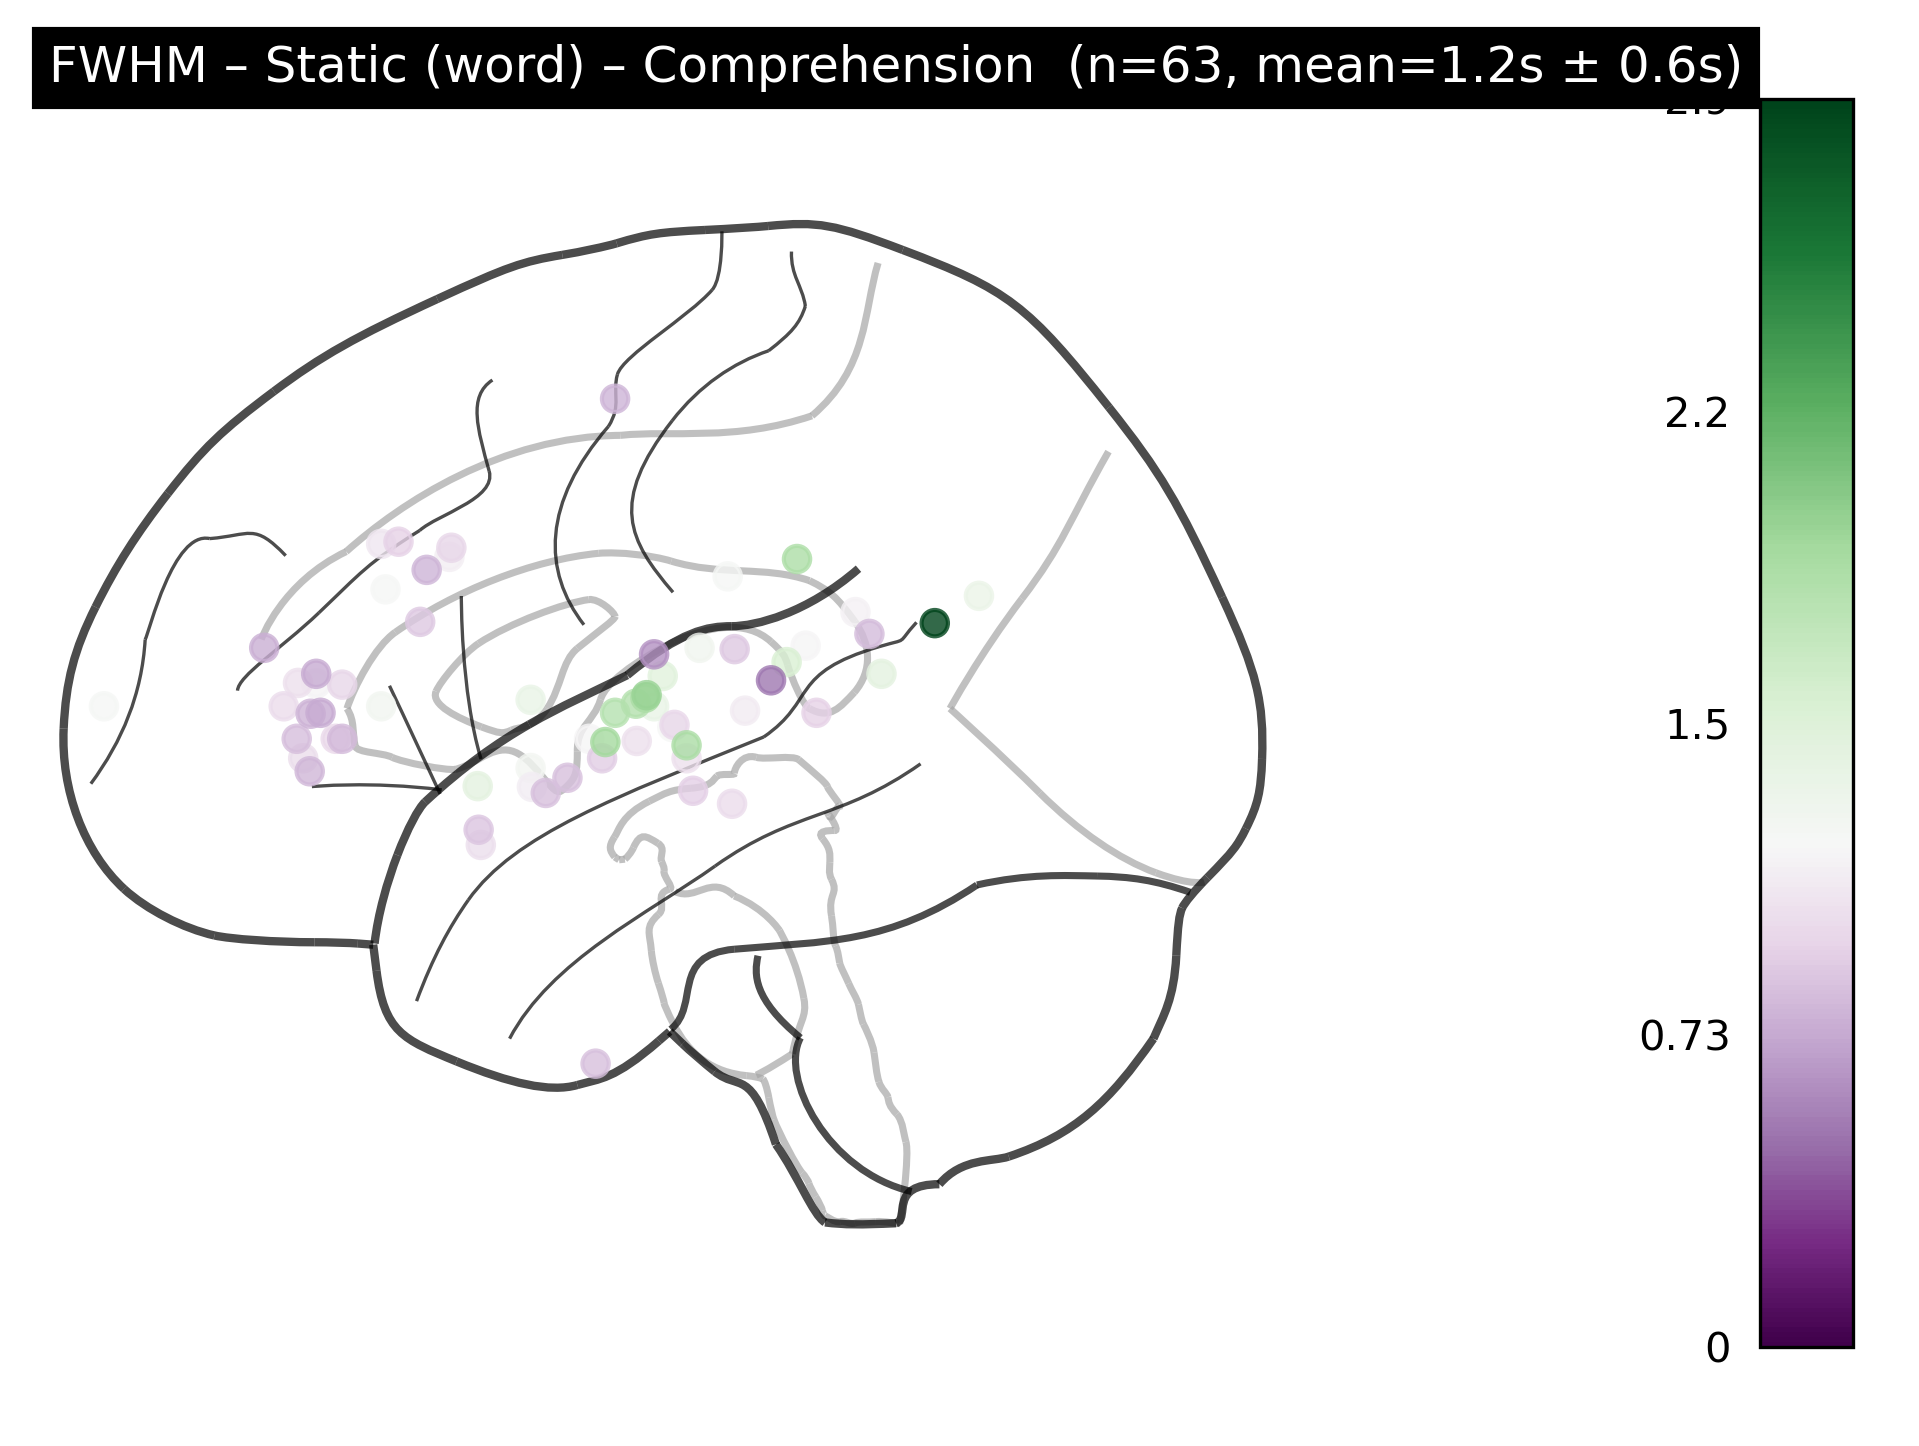

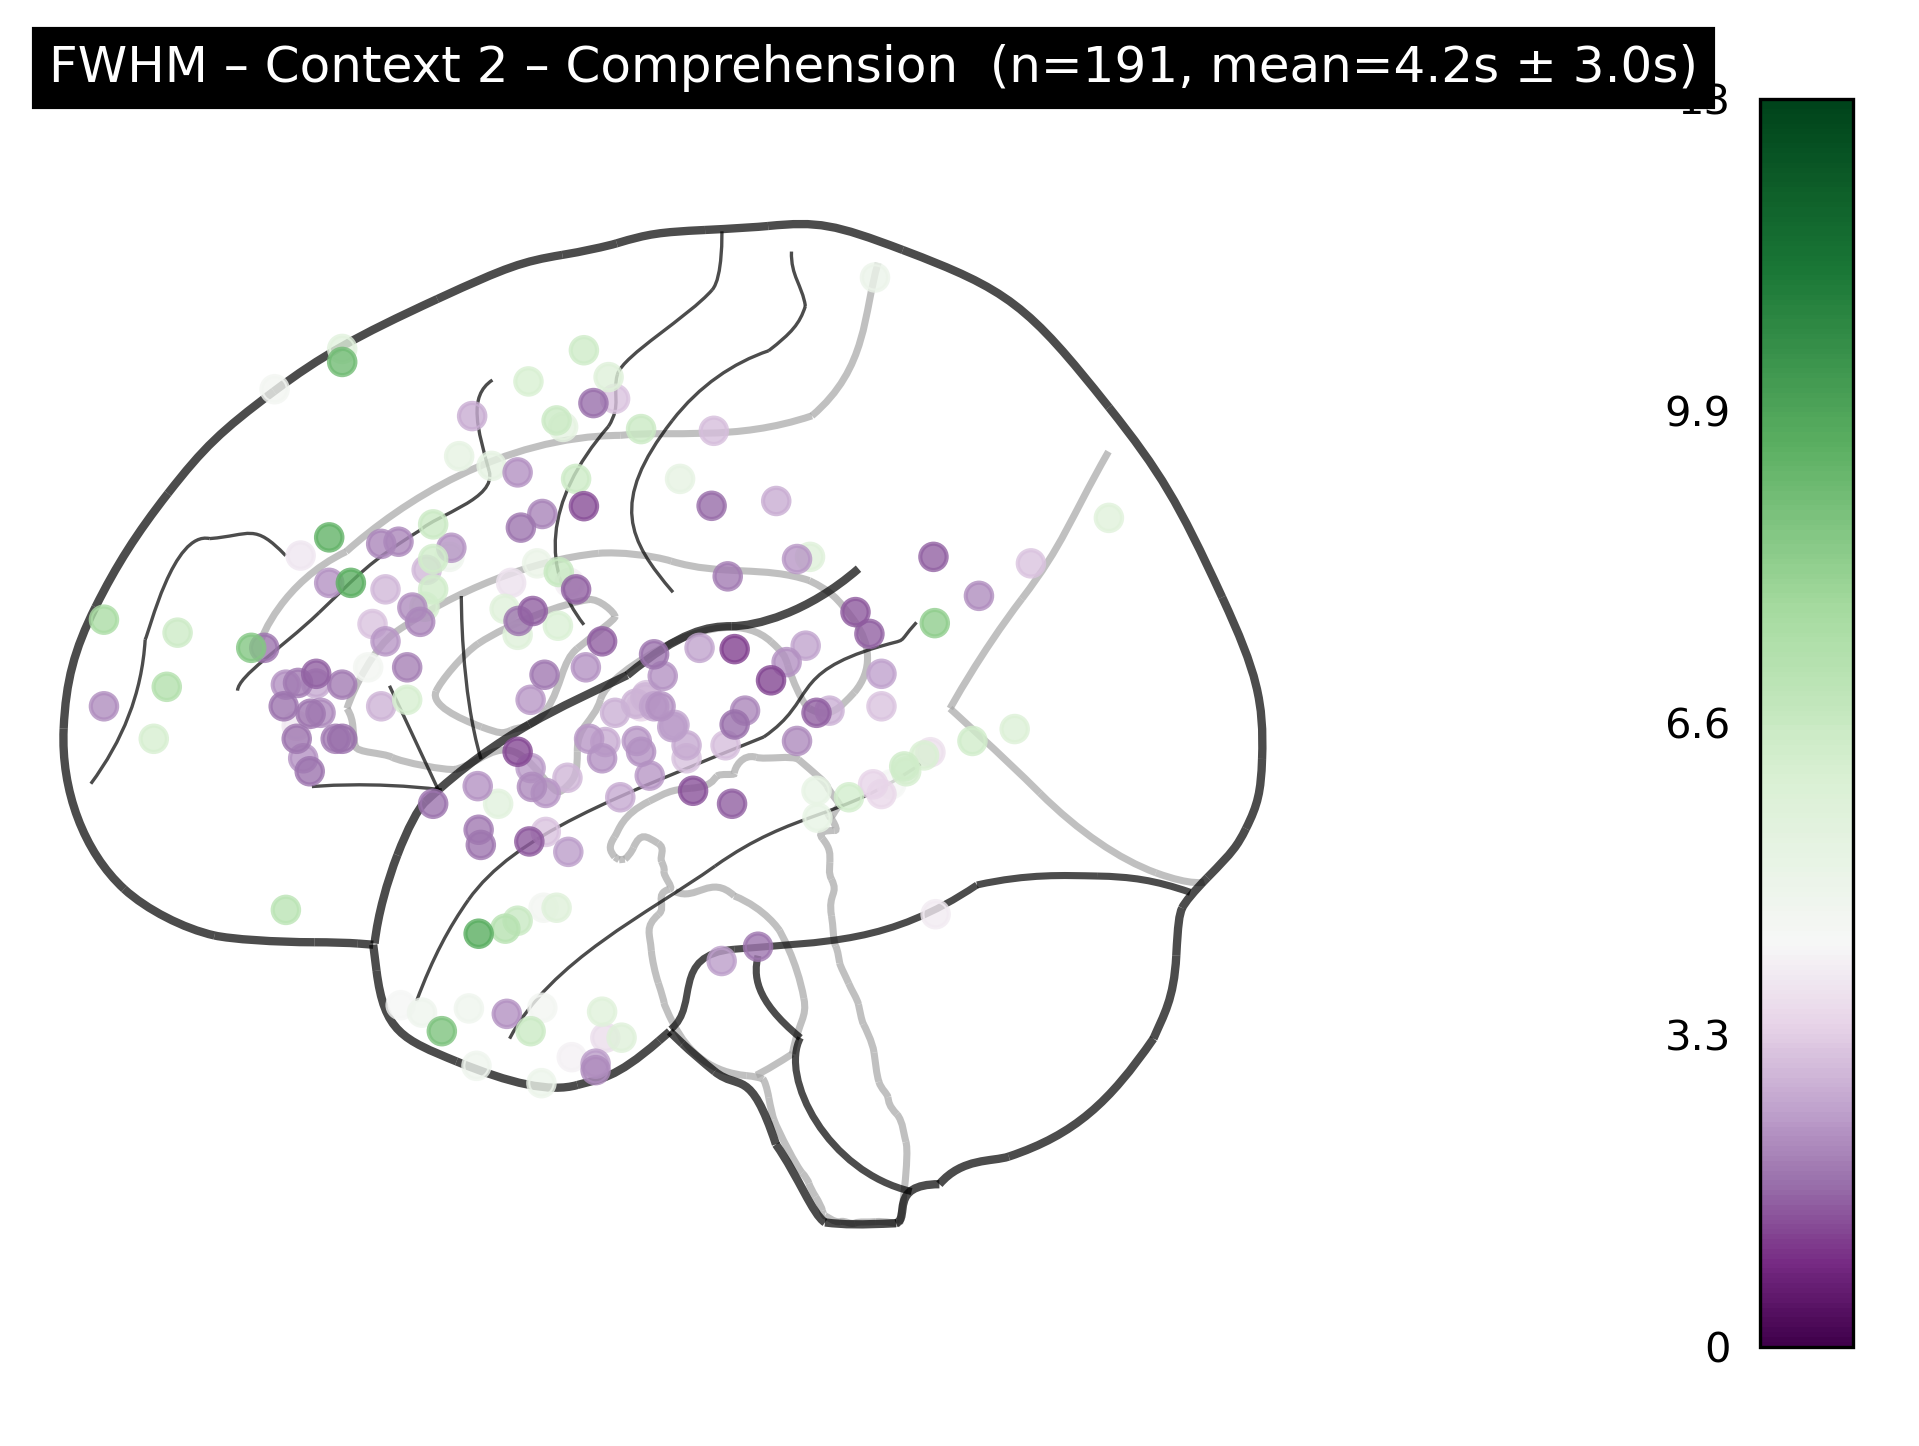

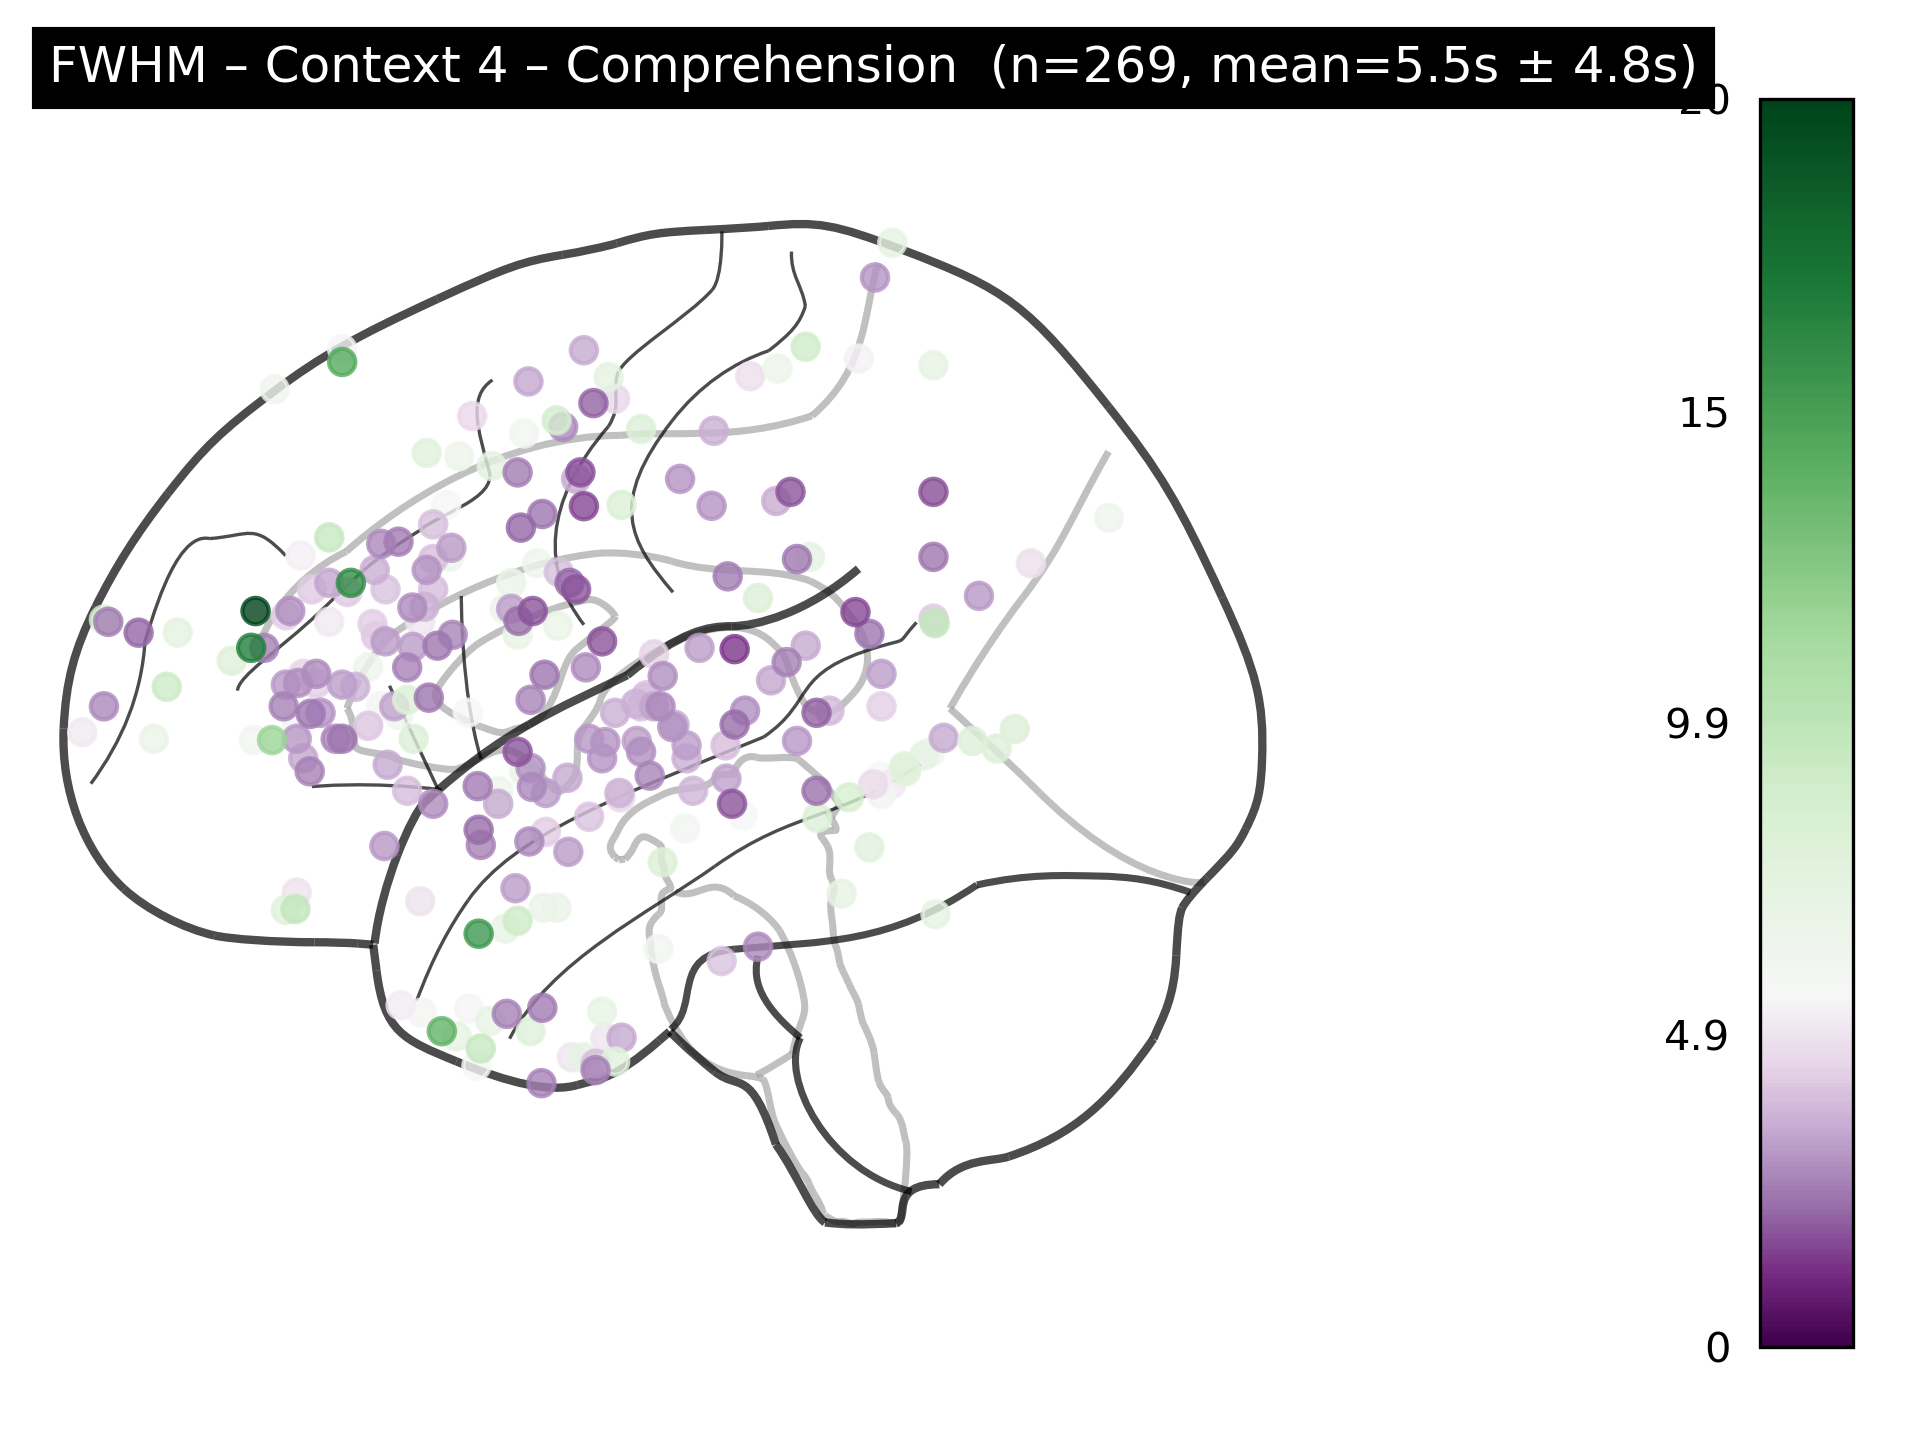

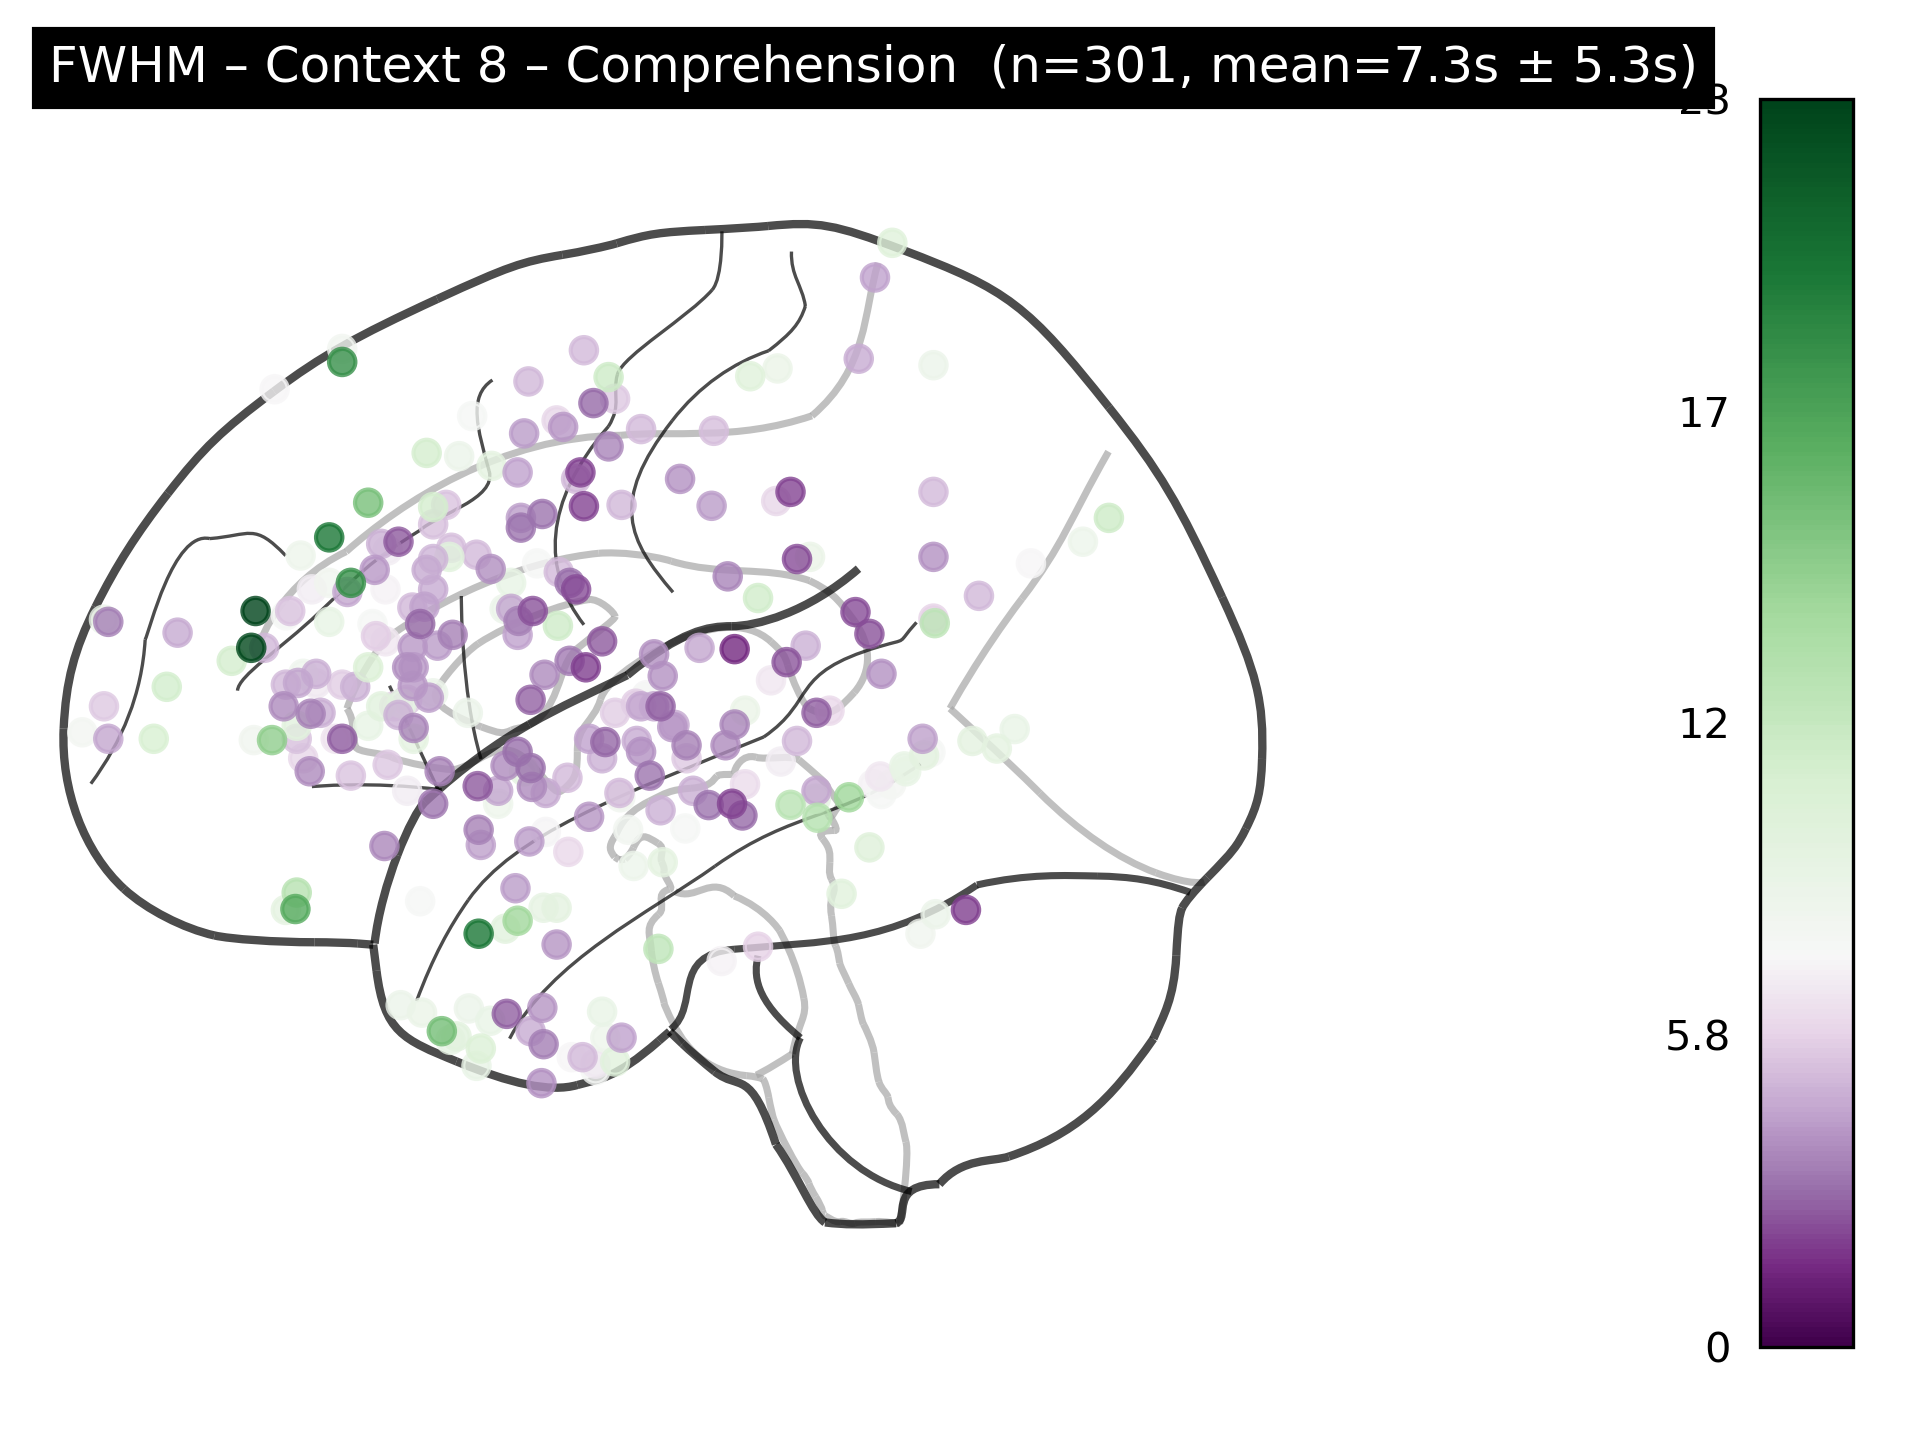

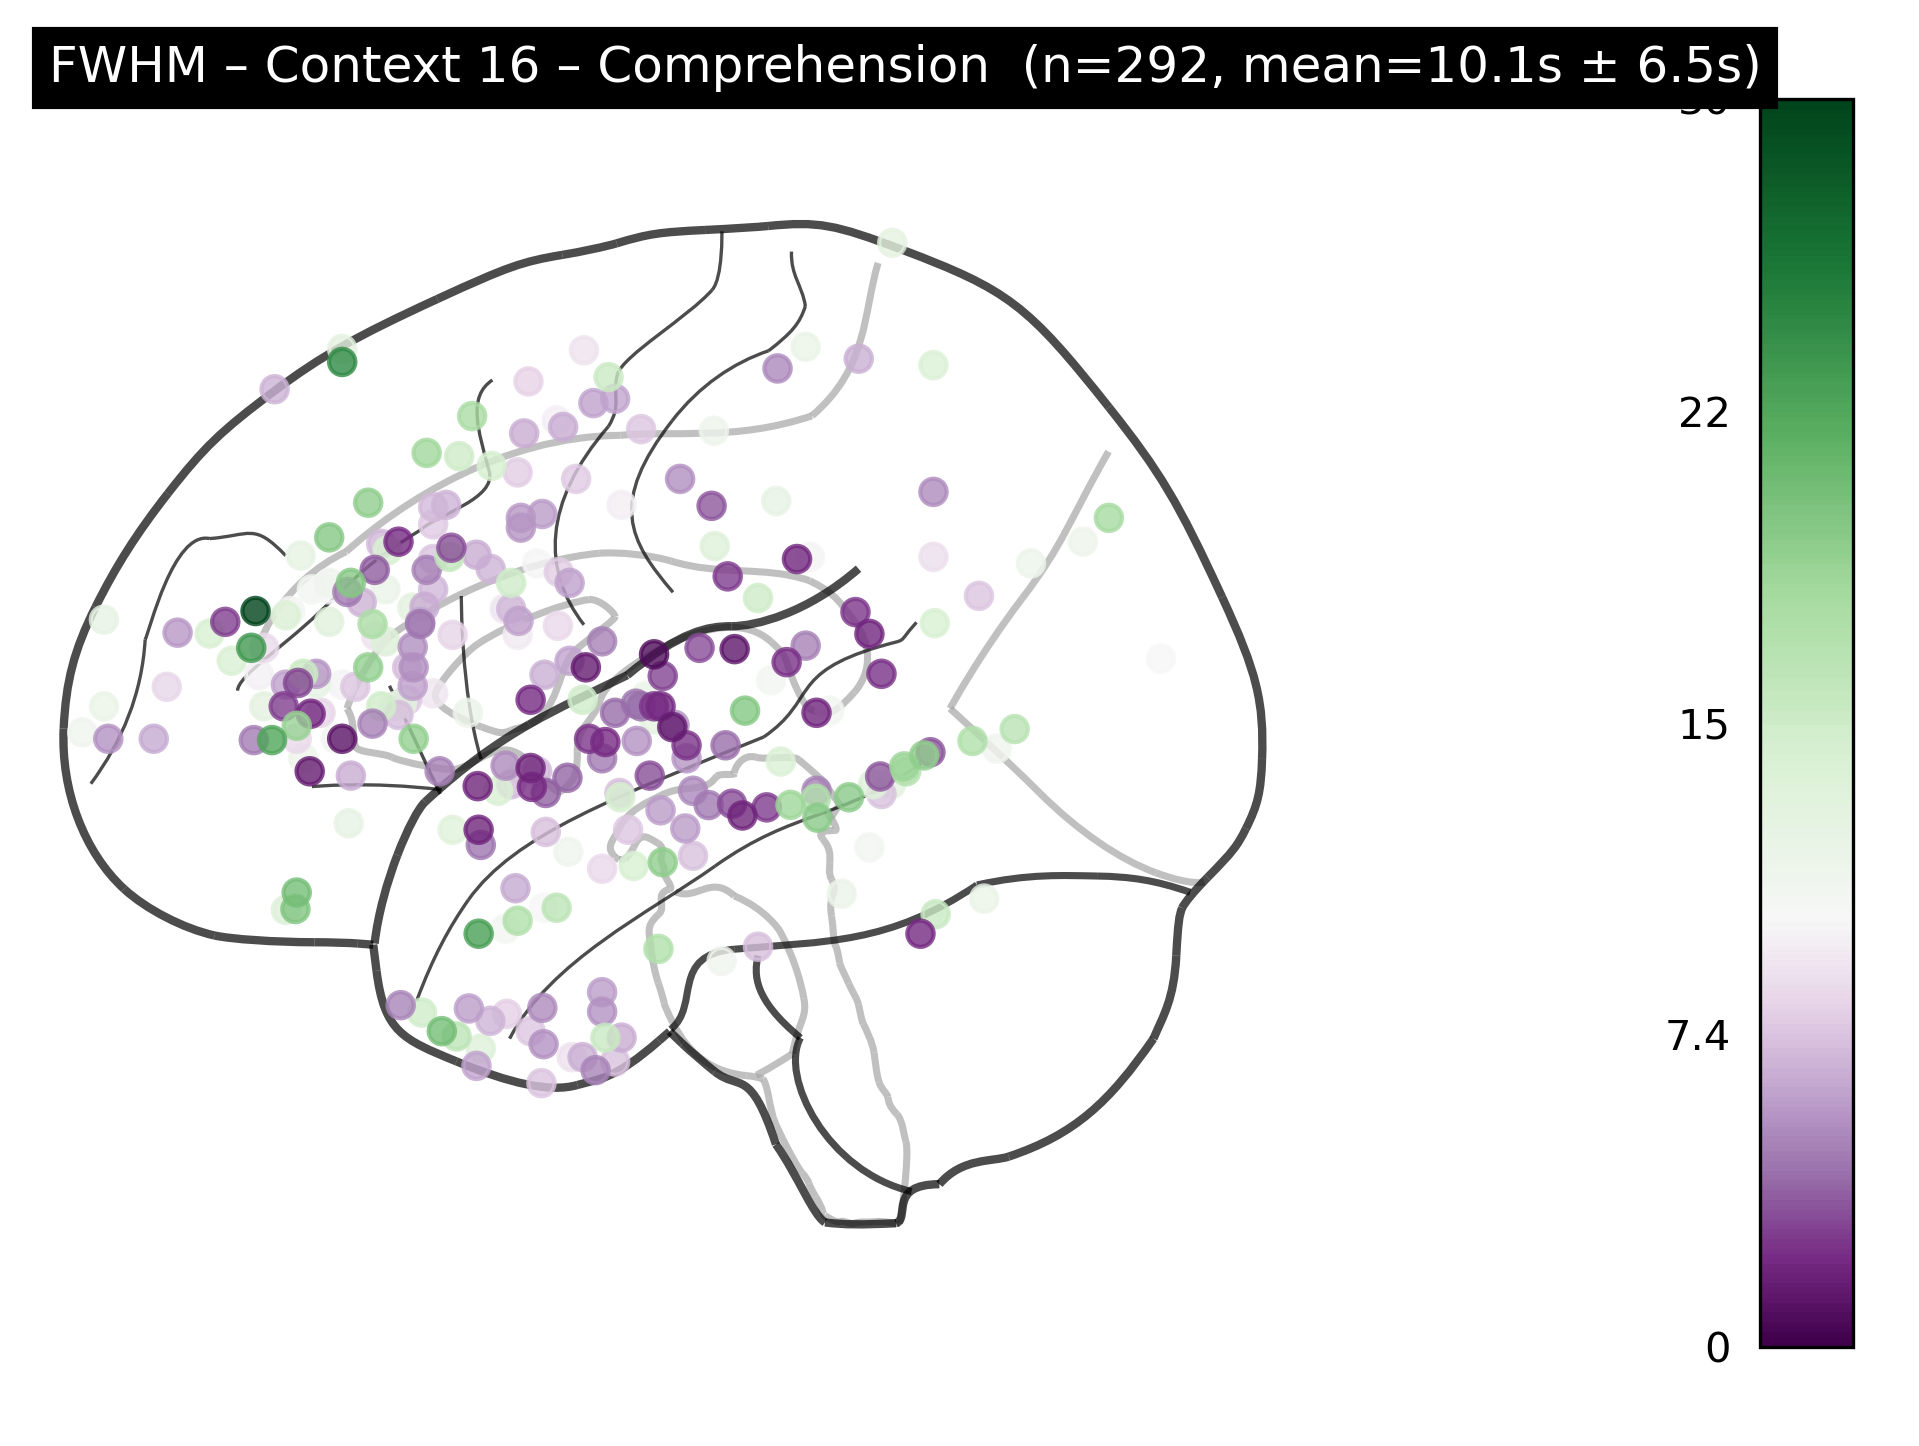

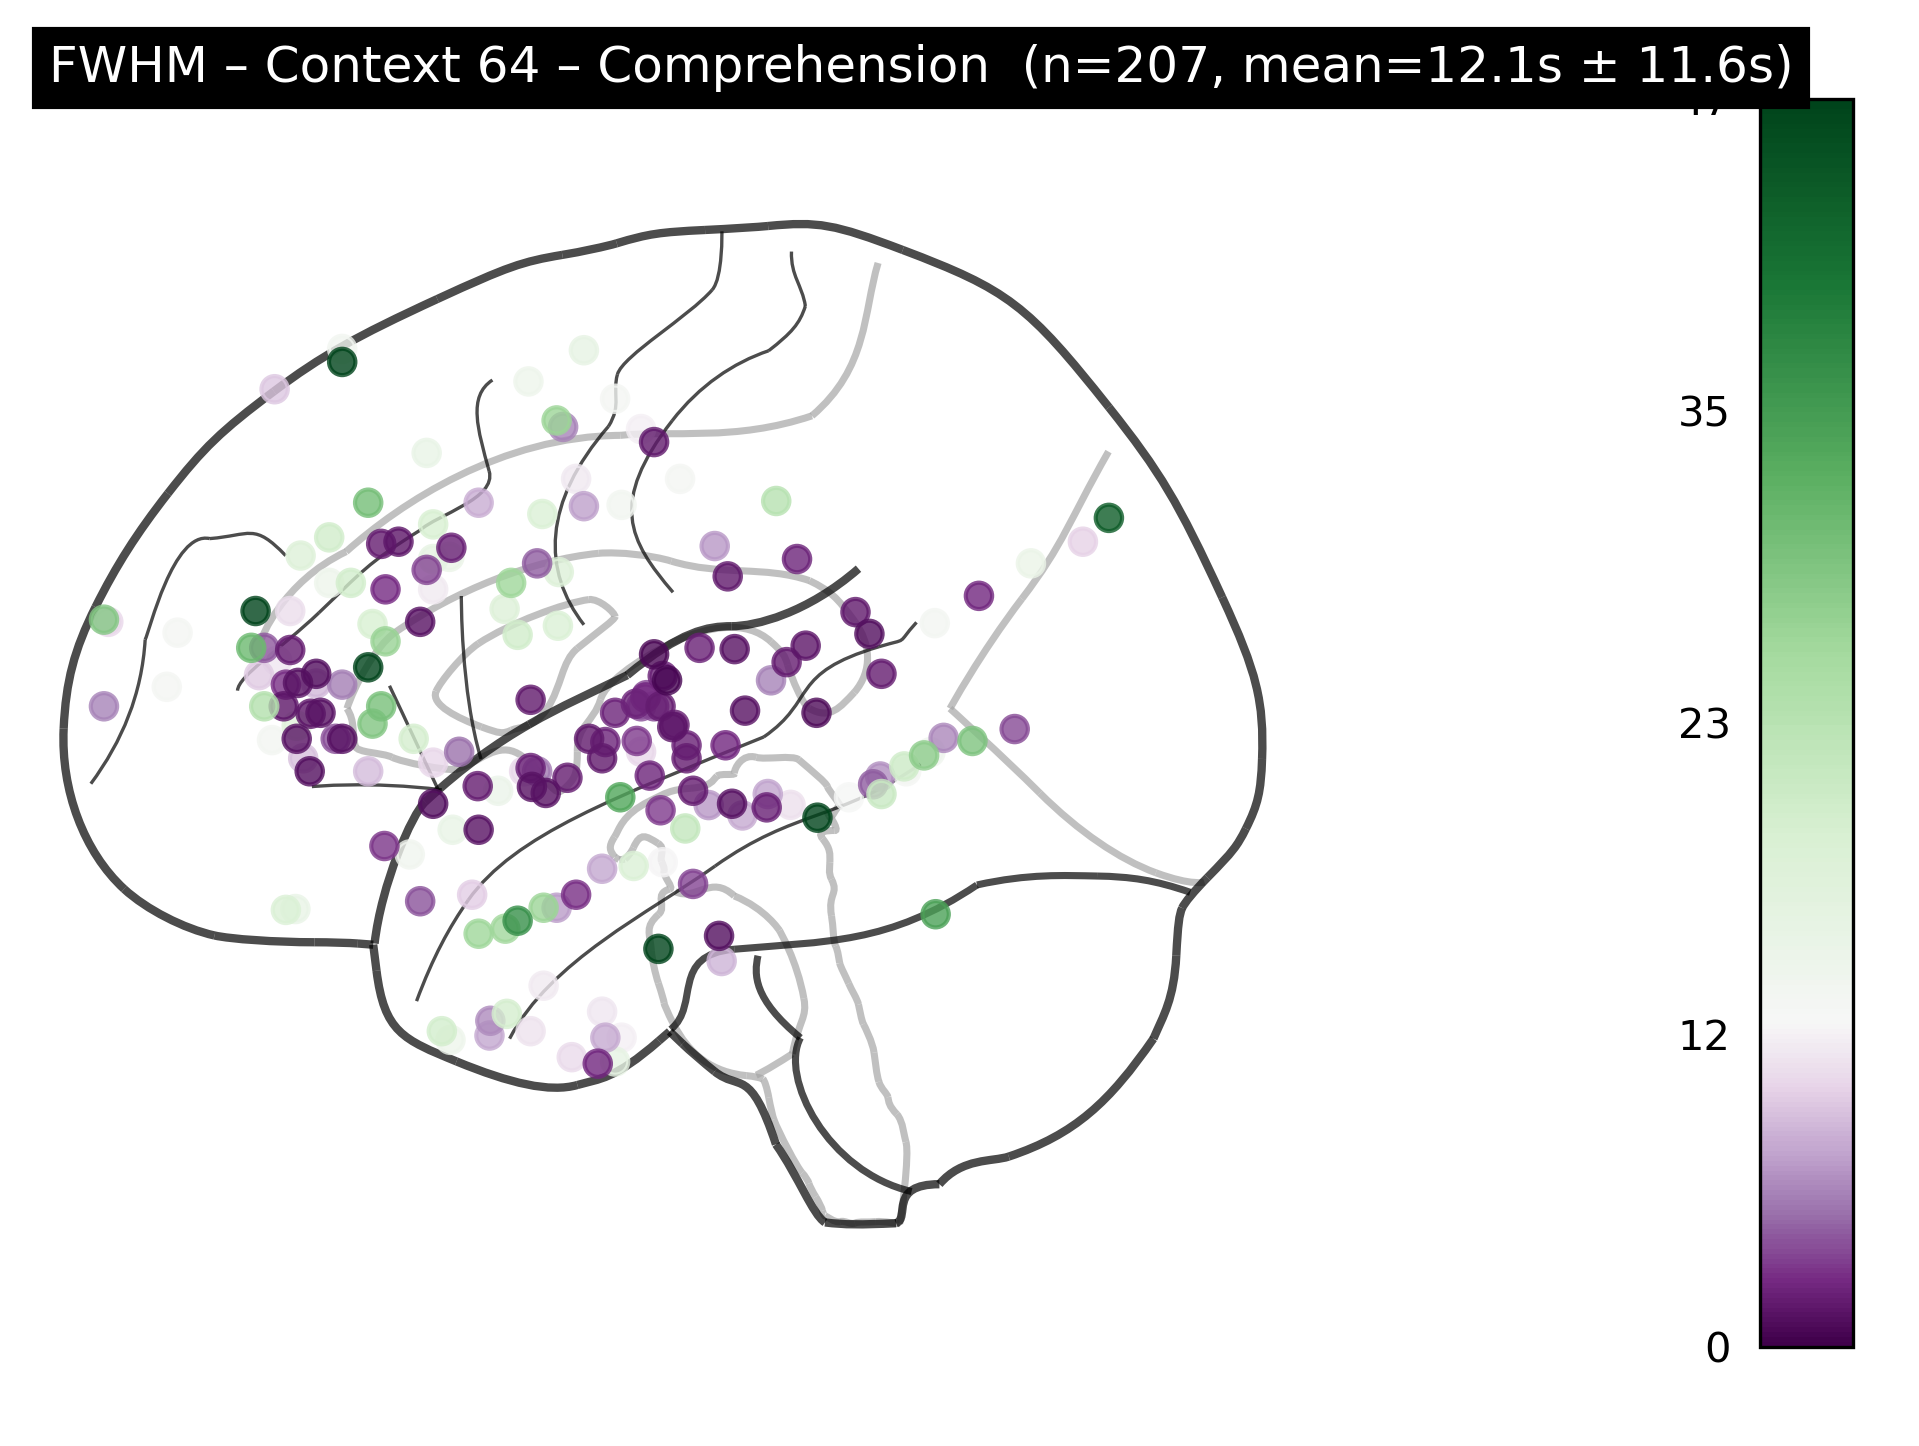

In [8]:
for name, *_ in datasets_def:
    fc = fwhm_comp[name]
    if fc.empty:
        print(f"No FWHM data for {name} (comp)")
        continue

    fc_plot = fc.copy()
    fc_plot['FWHM_s'] = fc_plot['FWHM'] / 1000
    mean_s = fc_plot['FWHM_s'].mean()
    std_s  = fc_plot['FWHM_s'].std()
    vmin_s = max(0, mean_s - 3 * std_s)
    vmax_s = mean_s + 3 * std_s

    norm = mcolors.TwoSlopeNorm(vmin=vmin_s, vcenter=mean_s, vmax=vmax_s)
    shifted_colors = copy.copy(plt.get_cmap('PRGn'))(norm(np.linspace(vmin_s, vmax_s, 256)))
    shifted_cmap = mcolors.ListedColormap(shifted_colors, name='PRGn_shifted')

    pu.plot_effect_glassbrain(
        fc_plot,
        effect_col='FWHM_s',
        cmap=shifted_cmap,
        vmin=vmin_s,
        vmax=vmax_s,
        title=f"FWHM – {name} – Comprehension  (n={len(fc)}, mean={mean_s:.1f}s ± {std_s:.1f}s)",
    )

## Brain Maps — Production

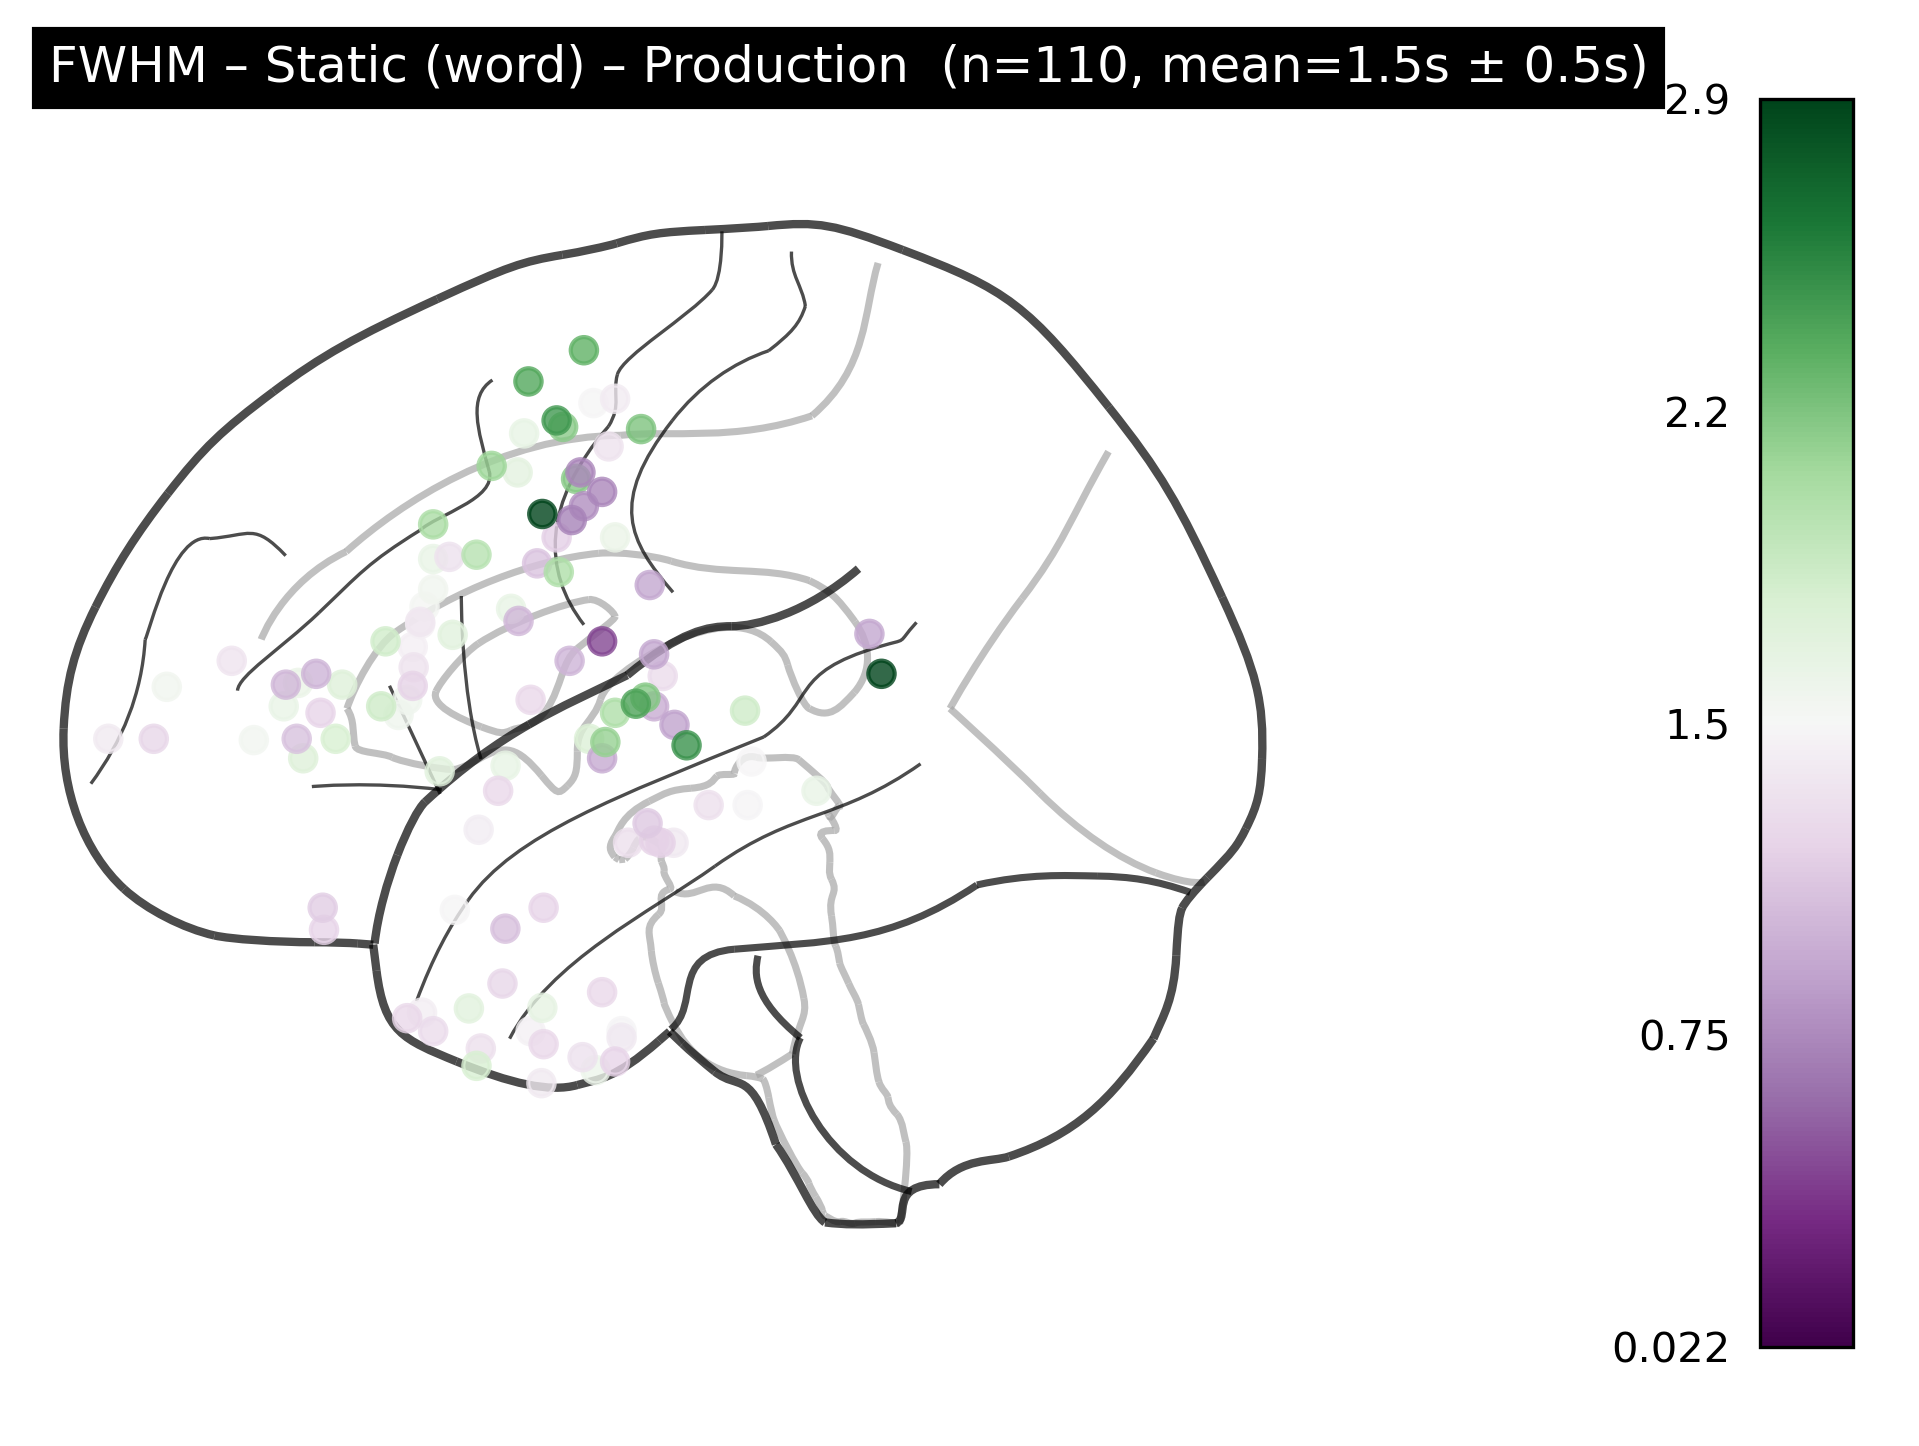

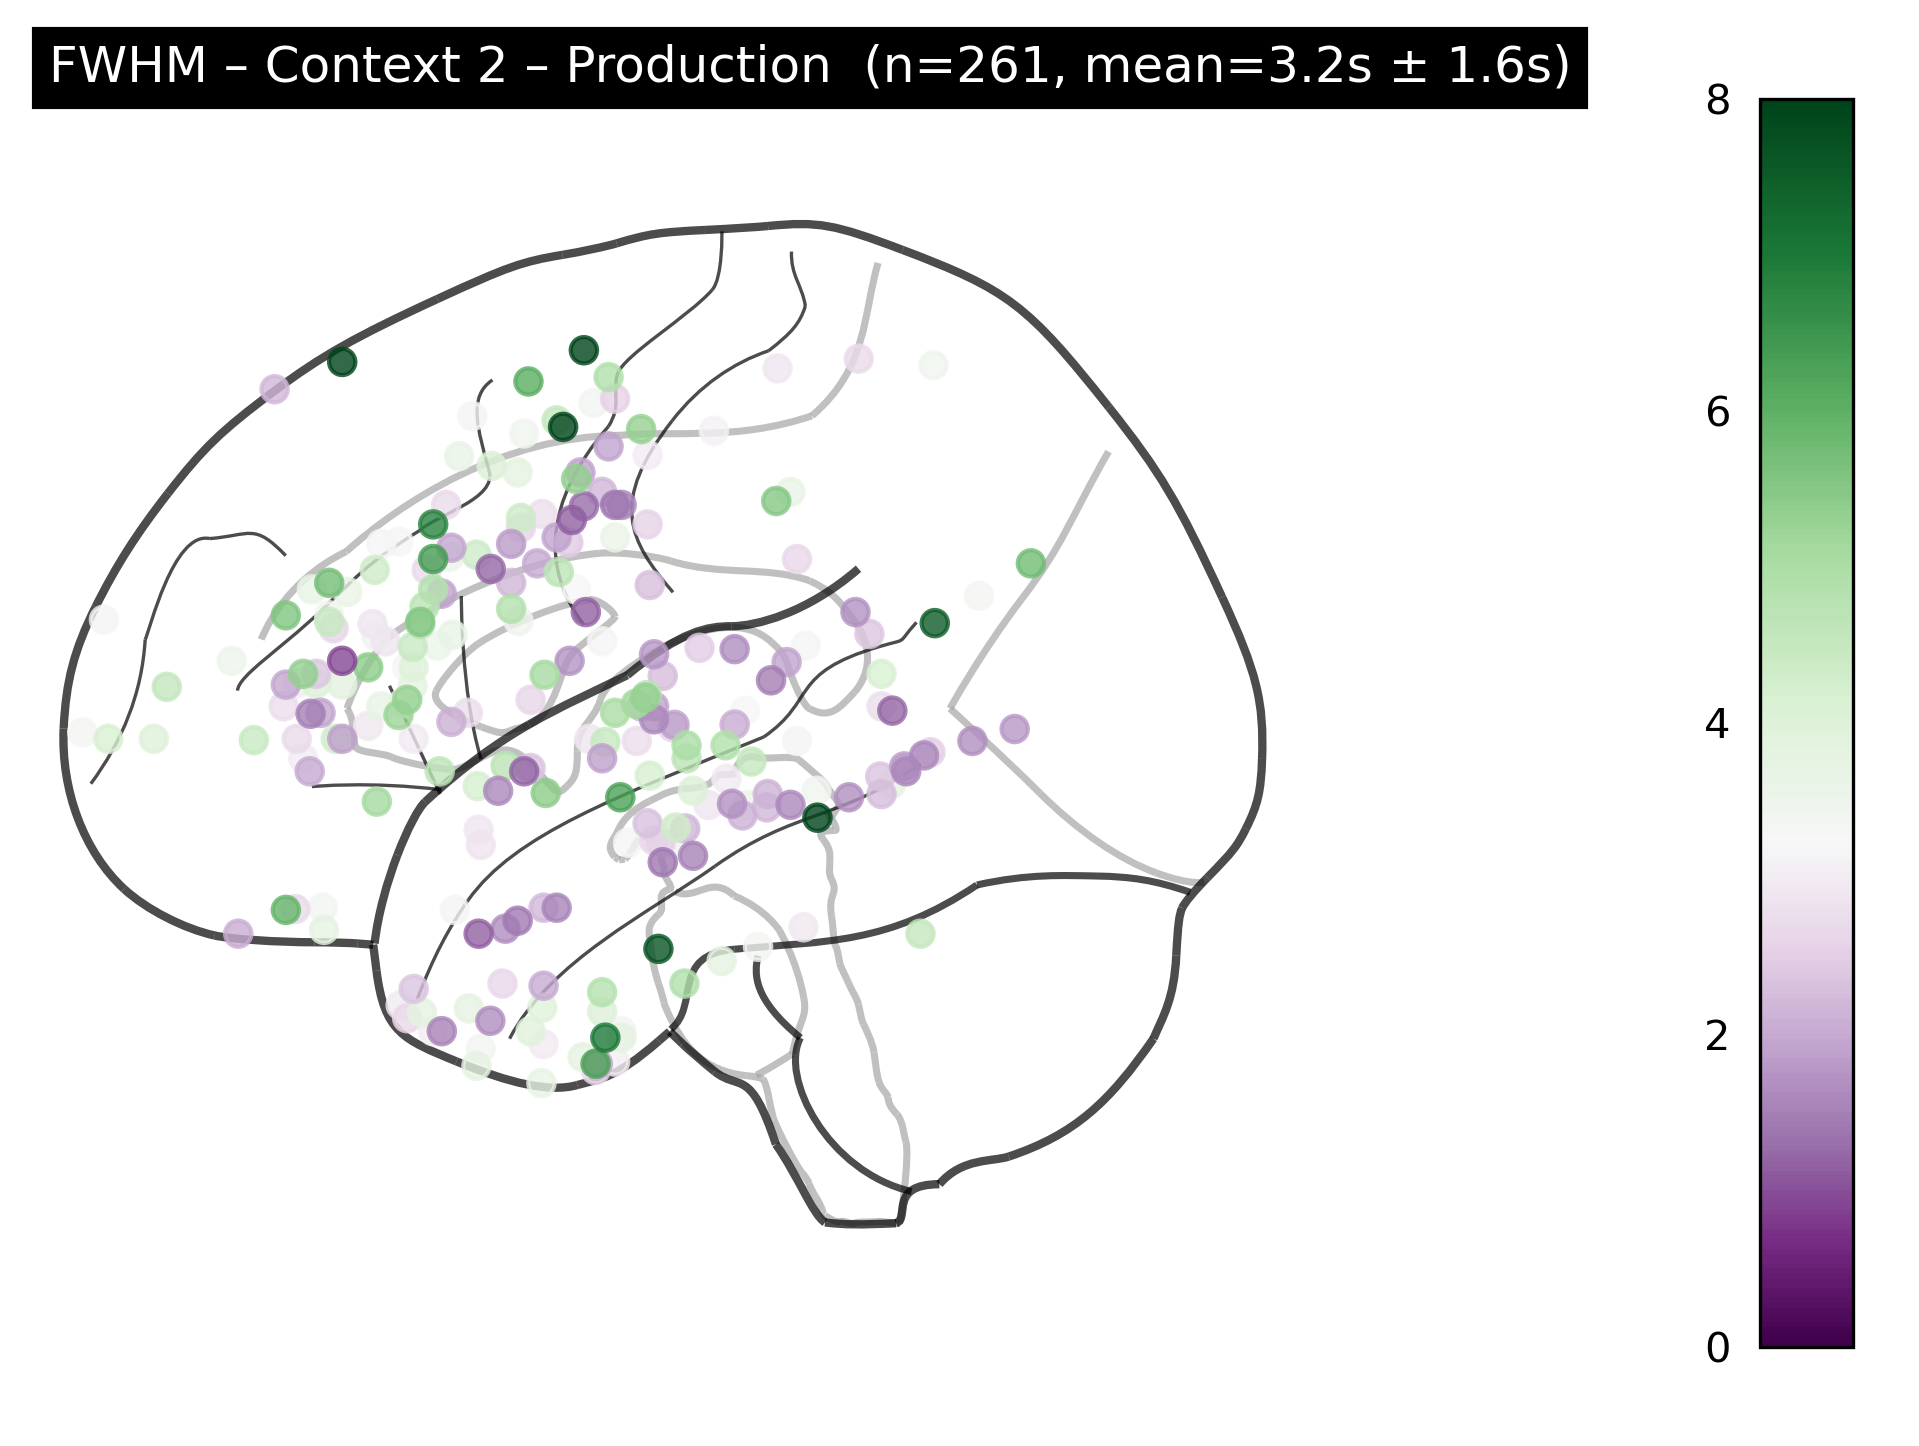

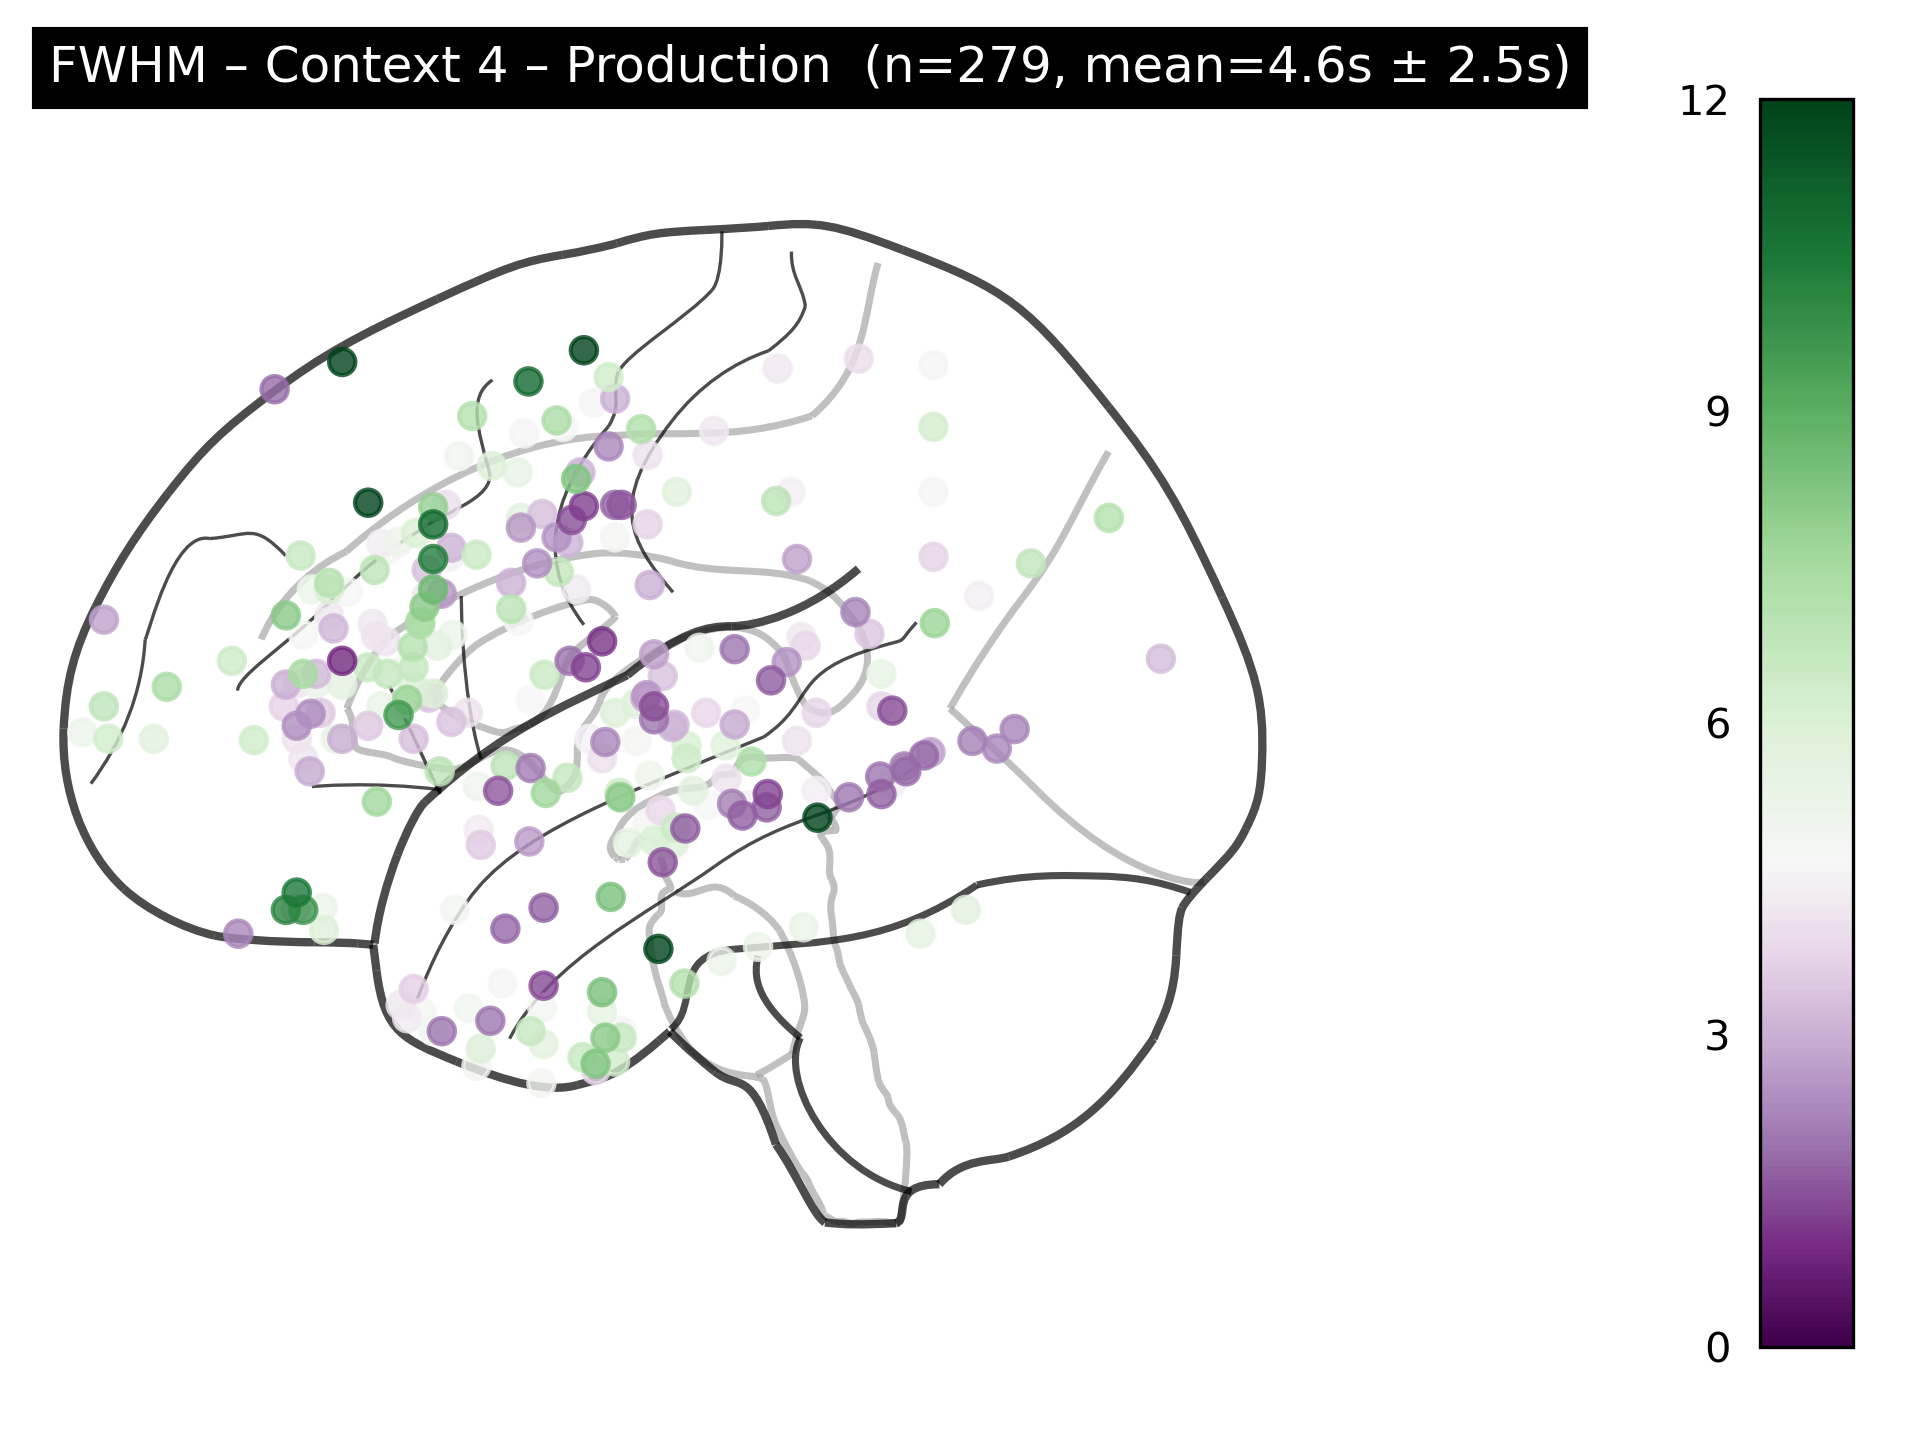

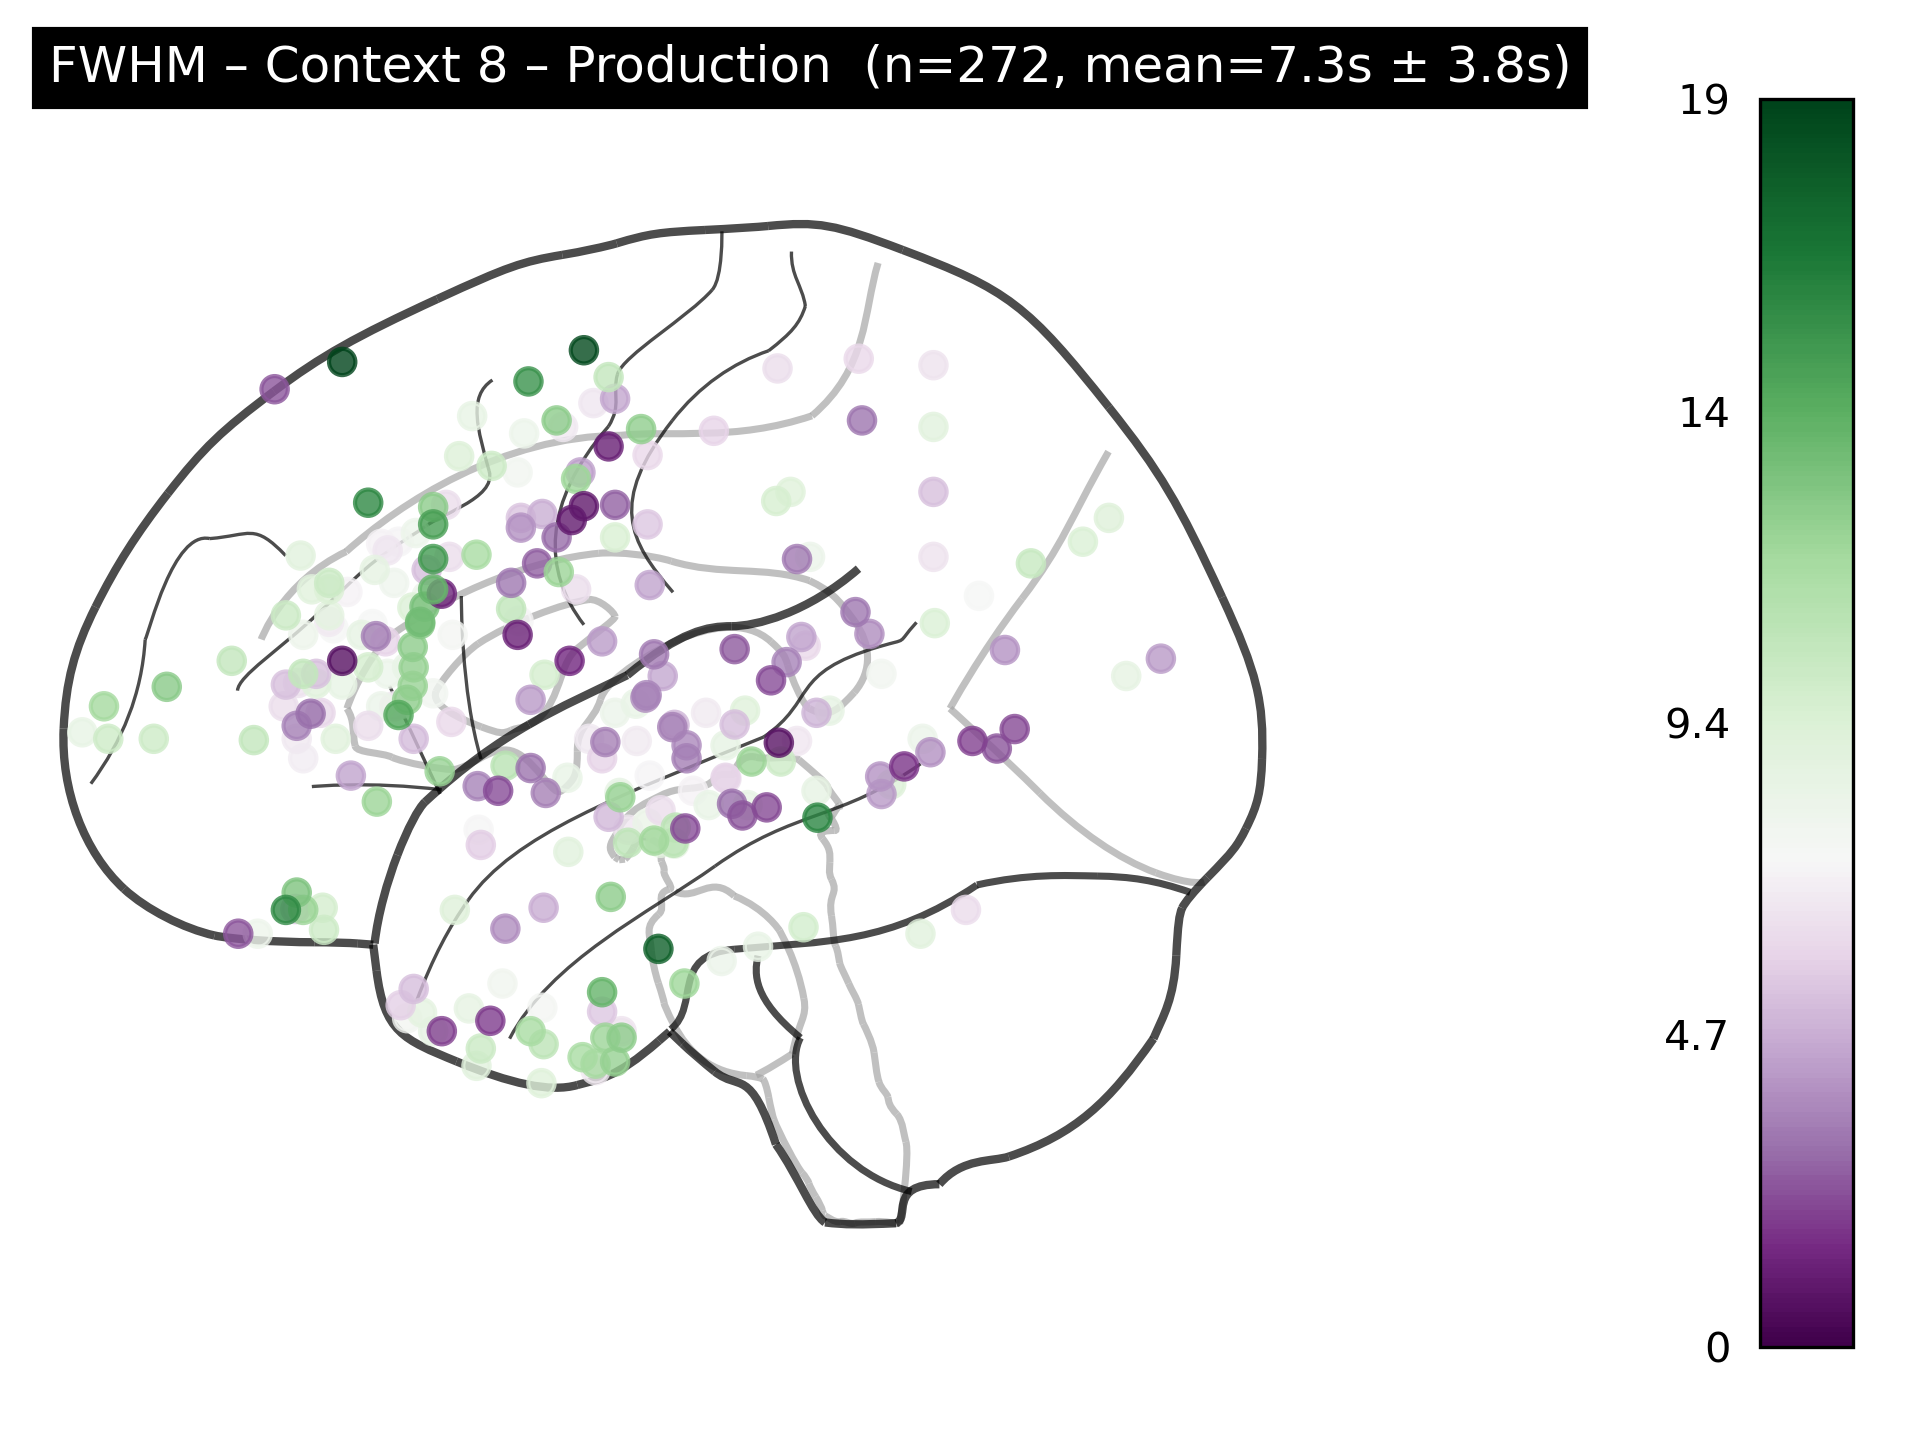

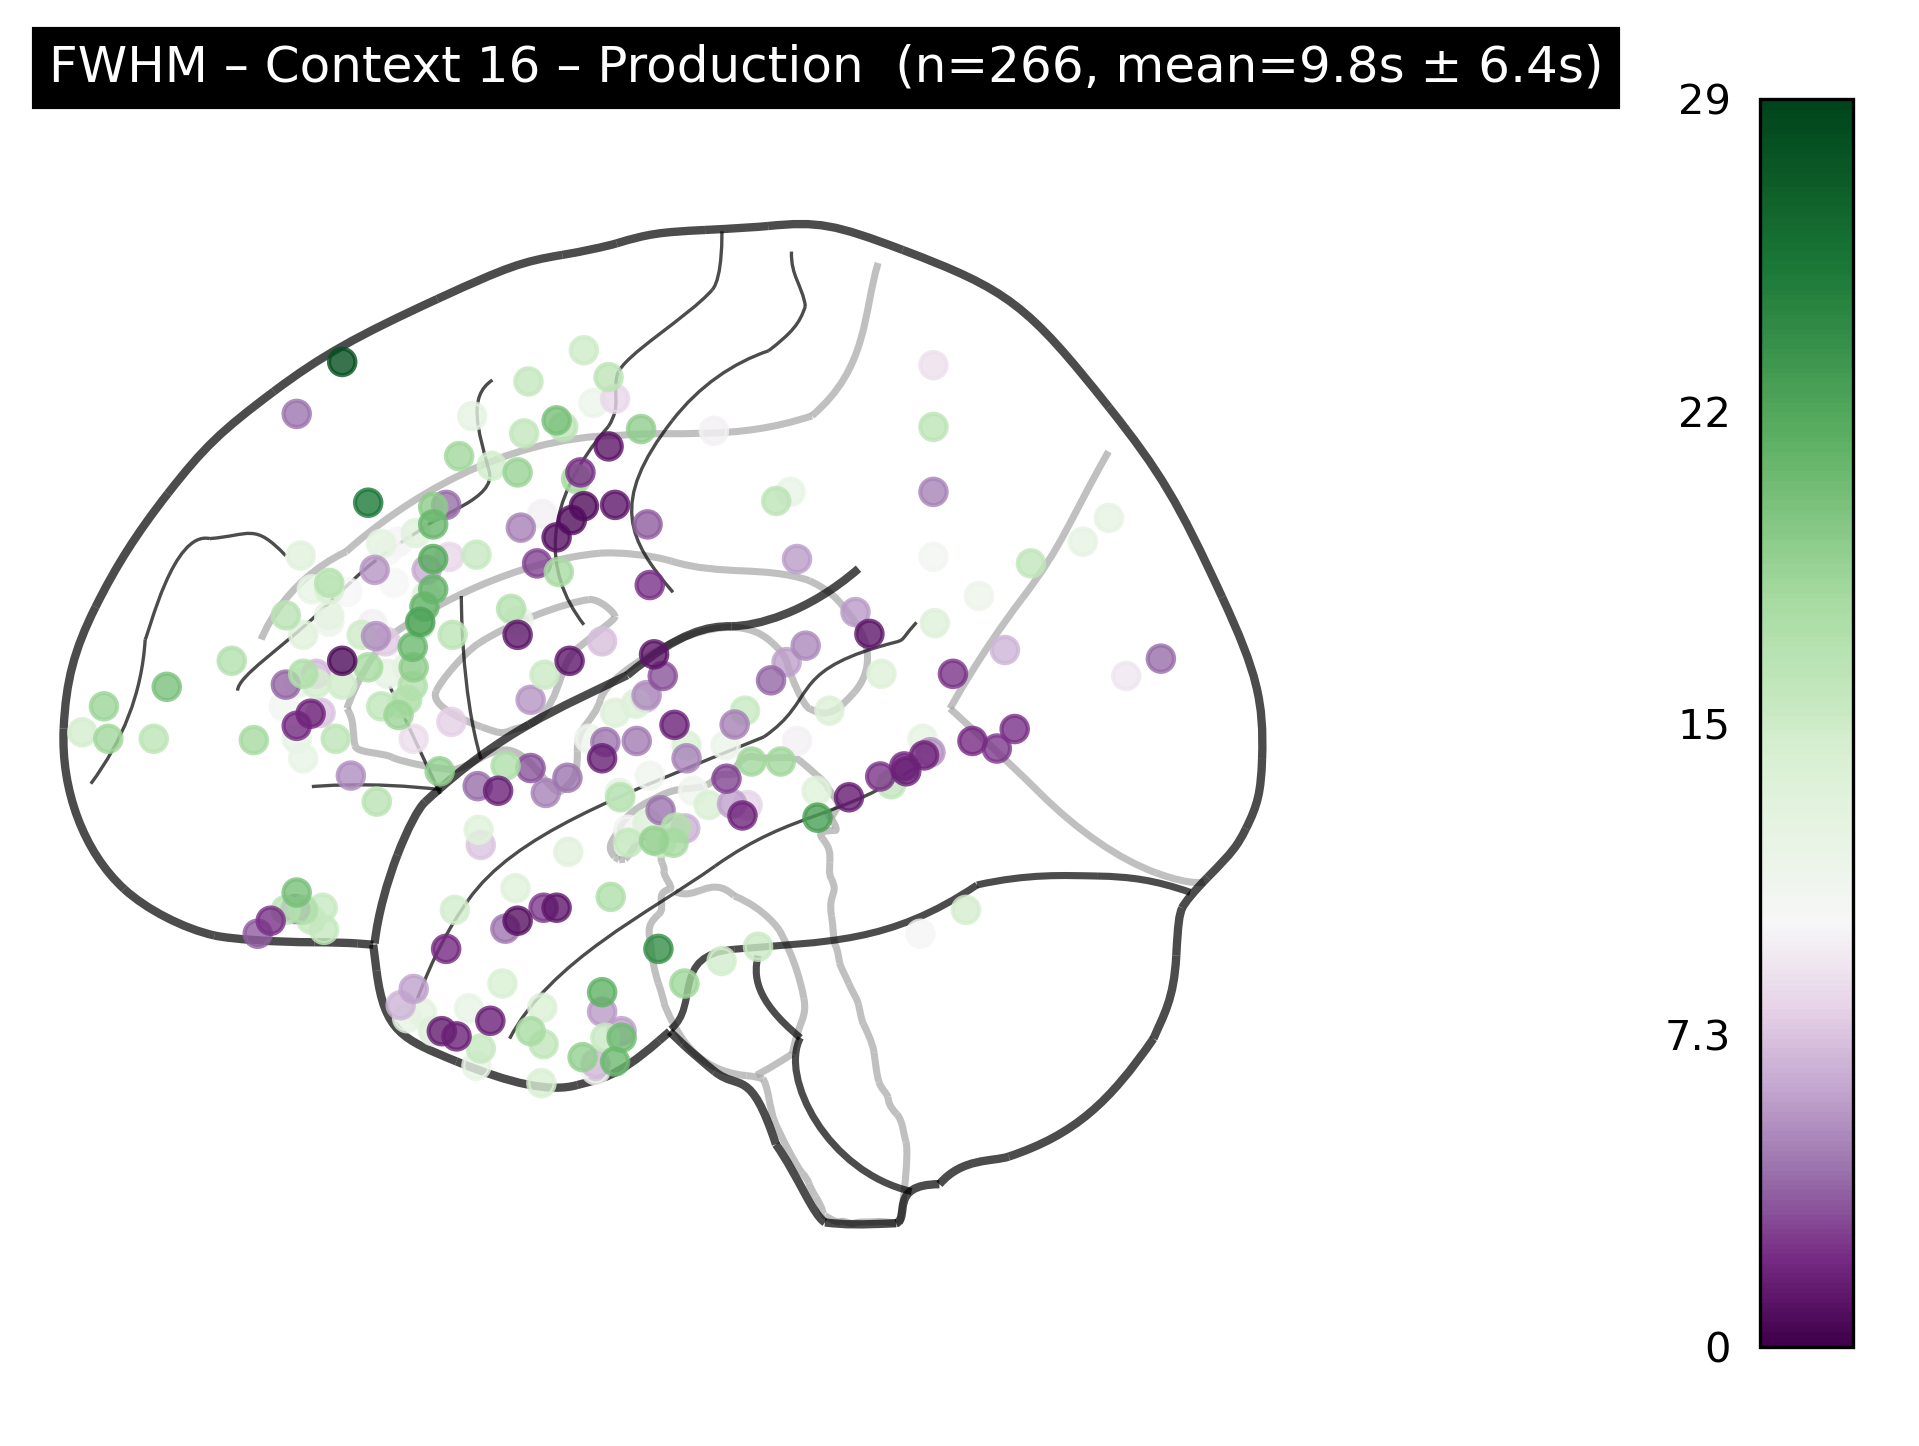

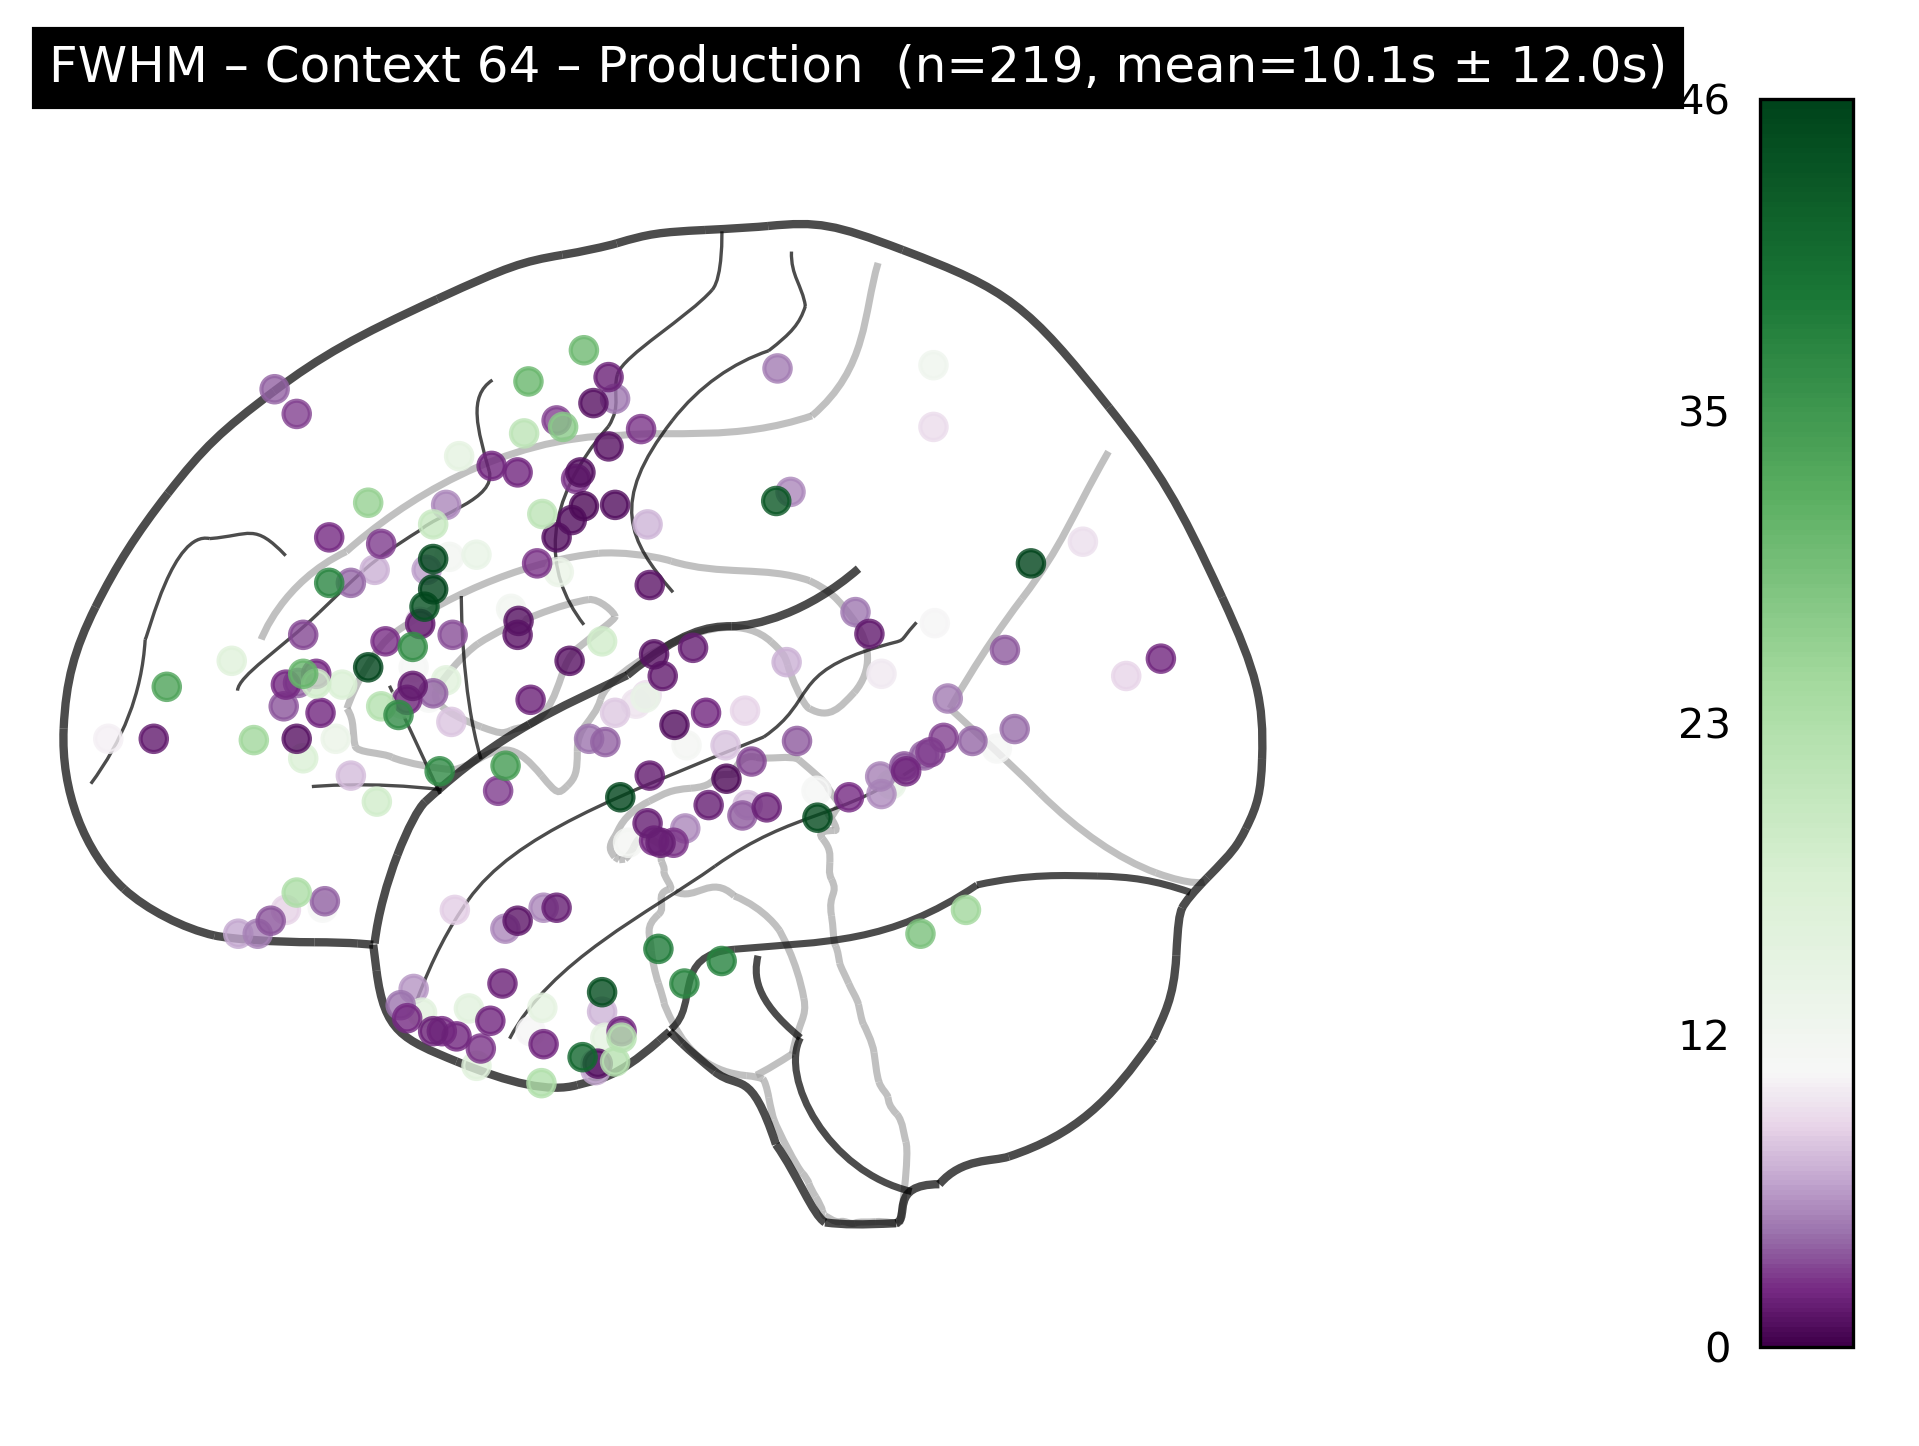

In [9]:
for name, *_ in datasets_def:
    fp = fwhm_prod[name]
    if fp.empty:
        print(f"No FWHM data for {name} (prod)")
        continue

    fp_plot = fp.copy()
    fp_plot['FWHM_s'] = fp_plot['FWHM'] / 1000
    mean_s = fp_plot['FWHM_s'].mean()
    std_s  = fp_plot['FWHM_s'].std()
    vmin_s = max(0, mean_s - 3 * std_s)
    vmax_s = mean_s + 3 * std_s

    norm = mcolors.TwoSlopeNorm(vmin=vmin_s, vcenter=mean_s, vmax=vmax_s)
    shifted_colors = copy.copy(plt.get_cmap('PRGn'))(norm(np.linspace(vmin_s, vmax_s, 256)))
    shifted_cmap = mcolors.ListedColormap(shifted_colors, name='PRGn_shifted')

    pu.plot_effect_glassbrain(
        fp_plot,
        effect_col='FWHM_s',
        cmap=shifted_cmap,
        vmin=vmin_s,
        vmax=vmax_s,
        title=f"FWHM – {name} – Production  (n={len(fp)}, mean={mean_s:.1f}s ± {std_s:.1f}s)",
    )

## Save to CSV (optional)

In [10]:
# out_dir = '/scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/results/roi_figures/future_past/fwhm_contexts'
# os.makedirs(out_dir, exist_ok=True)

# all_comp_rows, all_prod_rows = [], []
# for name, *_ in datasets_def:
#     fc, fp = fwhm_comp[name].copy(), fwhm_prod[name].copy()
#     if not fc.empty:
#         fc['context'] = name; all_comp_rows.append(fc)
#     if not fp.empty:
#         fp['context'] = name; all_prod_rows.append(fp)

# if all_comp_rows:
#     pd.concat(all_comp_rows, ignore_index=True).to_csv(f"{out_dir}/fwhm_all_contexts_comp.csv", index=False)
#     print(f"Saved comp FWHM → {out_dir}/fwhm_all_contexts_comp.csv")
# if all_prod_rows:
#     pd.concat(all_prod_rows, ignore_index=True).to_csv(f"{out_dir}/fwhm_all_contexts_prod.csv", index=False)
#     print(f"Saved prod FWHM → {out_dir}/fwhm_all_contexts_prod.csv")

## Component Boxplots: Max Joint Peak & AUC by Component (Word / Future / Past)

Electrodes are thresholded by the union rule: **kept if joint peak correlation > 0.1 in at least one context model** (2/4/8/16/64), computed separately for comprehension and production. Static word-only is excluded here since it has no joint/future/past partition.

- **Plot 1**: max joint correlation within **[-1000, 1000] ms**, one box per context.
- **Plot 2**: AUC per component — **word** over all lags (±30 s), **future** (`sentence`) over **[-2000, 0] ms**, **past** (`sentence2`) over **[0, 2000] ms**. Each component gets its own panel (AUC scales with window width, so word/future/past are not comparable on the same axis) with one box per context inside.

In [ ]:
# ── Helpers for component-level analysis ─────────────────────────────────────

def rename_lags_to_ms(df, lags_ms):
    """Rename index-based lag columns ('0'..'N-1') to actual lag values in ms."""
    lag_cols = [c for c in df.columns if str(c).isdigit()]
    lag_cols_sorted = sorted(lag_cols, key=lambda c: int(c))
    if len(lag_cols_sorted) != len(lags_ms):
        raise ValueError(f"Column count {len(lag_cols_sorted)} != lags_ms count {len(lags_ms)}")
    rename_map = {c: float(lags_ms[i]) for i, c in enumerate(lag_cols_sorted)}
    return df.rename(columns=rename_map)


def get_joint_threshold_set(raw_dict, thresh=0.1):
    """(subject, electrode) pairs whose joint peak correlation exceeds thresh in ANY context."""
    keep = set()
    for df in raw_dict.values():
        df_j = df[df['label3'] == 'joint']
        lag_cols = [c for c in df_j.columns if isinstance(c, (int, float))]
        mask = df_j[lag_cols].max(axis=1) > thresh
        for _, row in df_j.loc[mask, ['subject', 'electrode']].iterrows():
            keep.add((str(row['subject']), str(row['electrode'])))
    return keep


def filter_to_set(df, keep_set):
    keep_keys = {f"{s}_{e}" for s, e in keep_set}
    key = df['subject'].astype(str) + "_" + df['electrode'].astype(str)
    return df[key.isin(keep_keys)].copy()


def max_in_window(df, label3_val, lag_start, lag_end):
    """Per-electrode max correlation within [lag_start, lag_end] ms, for one label3."""
    df_l = df[df['label3'] == label3_val]
    lag_cols = [c for c in df_l.columns if isinstance(c, (int, float)) and lag_start <= c <= lag_end]
    out = df_l[['subject', 'electrode', 'roi']].copy()
    out['max_corr'] = df_l[lag_cols].max(axis=1).values
    return out


def calculate_auc_clipped(df, label3_val, lag_start, lag_end):
    """Like pu.calculate_auc, but clips correlations to >= 0 before integrating
    so negative dips don't subtract from the area under the curve."""
    from scipy import integrate

    df_filt = df[df['label3'] == label3_val]
    lag_cols = sorted(c for c in df_filt.columns if isinstance(c, (int, float)) and lag_start <= c <= lag_end)
    if not lag_cols:
        return pd.DataFrame(columns=['subject', 'electrode', 'roi', 'label3', 'lag_start', 'lag_end', 'auc', 'n_lags'])

    results = []
    for _, row in df_filt.iterrows():
        vals = np.clip(row[lag_cols].values.astype(float), 0, None)
        auc = integrate.trapezoid(vals, x=lag_cols)
        results.append({
            'subject': row['subject'],
            'electrode': row['electrode'],
            'roi': row.get('roi', 'unknown'),
            'label3': label3_val,
            'lag_start': lag_start,
            'lag_end': lag_end,
            'auc': auc,
            'n_lags': len(lag_cols),
        })
    return pd.DataFrame(results)

In [12]:
# Reload the context models keeping ALL label3 rows (joint, word, sentence, sentence2) —
# the FWHM section above filtered to a single label3 early, so we reload here.
context_only_def = [d for d in datasets_def if d[0] != "Static (word)"]
context_order = [d[0] for d in context_only_def]

raw_comp = {}
raw_prod = {}

for name, comp_path, prod_path, is_lag60, _ in context_only_def:
    df_c = pu.add_roi_label_to_results(pd.read_csv(comp_path))
    df_p = pu.add_roi_label_to_results(pd.read_csv(prod_path))
    if is_lag60:
        df_c = trim_lags_to_window(df_c, 600, 1800)
        df_p = trim_lags_to_window(df_p, 600, 1800)
    raw_comp[name] = rename_lags_to_ms(df_c, LAGS_ALL)
    raw_prod[name] = rename_lags_to_ms(df_p, LAGS_ALL)
    print(f"  {name:12s}  comp={len(raw_comp[name]):4d} rows   prod={len(raw_prod[name]):4d} rows   "
          f"label3={sorted(raw_comp[name]['label3'].unique())}")

  Context 2     comp=2644 rows   prod=2648 rows   label3=['joint', 'sentence', 'sentence2', 'word']
  Context 4     comp=2644 rows   prod=2648 rows   label3=['joint', 'sentence', 'sentence2', 'word']
  Context 8     comp=2644 rows   prod=2648 rows   label3=['joint', 'sentence', 'sentence2', 'word']
  Context 16    comp=2644 rows   prod=2644 rows   label3=['joint', 'sentence', 'sentence2', 'word']
  Context 64    comp=2644 rows   prod=2648 rows   label3=['joint', 'sentence', 'sentence2', 'word']


In [13]:
thresh_set_comp = get_joint_threshold_set(raw_comp, thresh=THRESH)
thresh_set_prod = get_joint_threshold_set(raw_prod, thresh=THRESH)

print(f"Comp: {len(thresh_set_comp)} electrodes pass joint > {THRESH} in ≥1 context")
print(f"Prod: {len(thresh_set_prod)} electrodes pass joint > {THRESH} in ≥1 context")

Comp: 347 electrodes pass joint > 0.1 in ≥1 context
Prod: 339 electrodes pass joint > 0.1 in ≥1 context


### Plot 1 — Max Joint Correlation in [-1000, 1000] ms

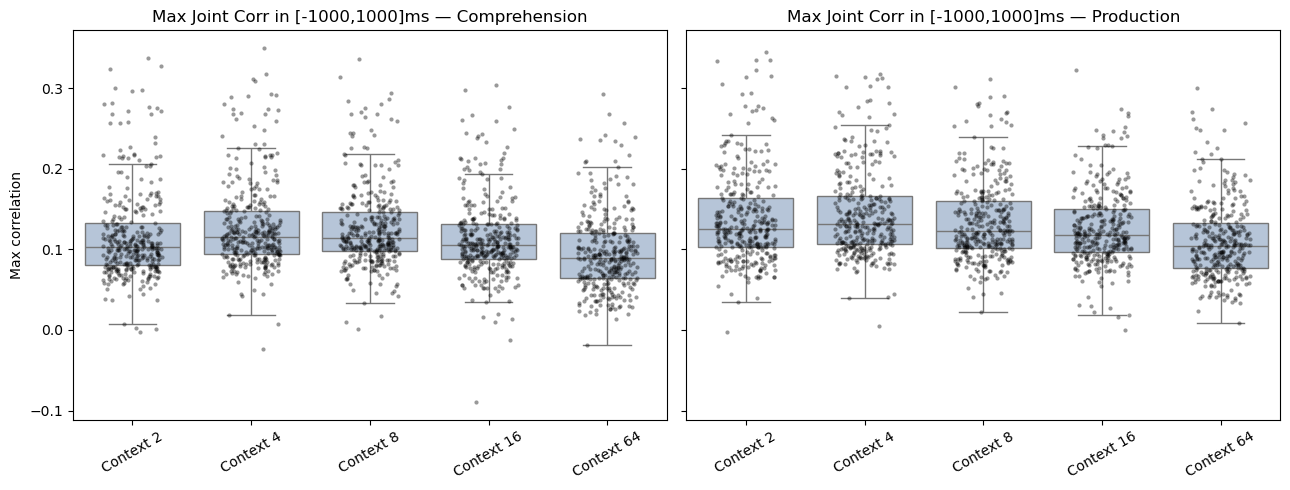

In [14]:
rows = []
for name in context_order:
    df_f = filter_to_set(raw_comp[name], thresh_set_comp)
    m = max_in_window(df_f, 'joint', -1000, 1000)
    m['context'] = name
    rows.append(m)
max_joint_comp = pd.concat(rows, ignore_index=True)

rows = []
for name in context_order:
    df_f = filter_to_set(raw_prod[name], thresh_set_prod)
    m = max_in_window(df_f, 'joint', -1000, 1000)
    m['context'] = name
    rows.append(m)
max_joint_prod = pd.concat(rows, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, df_plot, mode_label in [(axes[0], max_joint_comp, 'Comprehension'), (axes[1], max_joint_prod, 'Production')]:
    sns.boxplot(data=df_plot, x='context', y='max_corr', order=context_order, showfliers=False, color='lightsteelblue', ax=ax)
    sns.stripplot(data=df_plot, x='context', y='max_corr', order=context_order, color='black', size=3, alpha=0.4, jitter=0.25, ax=ax)
    ax.set_title(f'Max Joint Corr in [-1000,1000]ms — {mode_label}')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
axes[0].set_ylabel('Max correlation')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

### Plot 2/3 — AUC by Component (Word / Future / Past), Separate Boxes per Component

In [ ]:
auc_windows = {
    'word':   (-30000, 30000),   # all lags
    'future': (-2000, 0),        # 'sentence' partition
    'past':   (0, 2000),         # 'sentence2' partition
}
label3_map = {'word': 'word', 'future': 'sentence', 'past': 'sentence2'}
component_order = ['word', 'future', 'past']


def compute_auc_long(raw_dict, thresh_set, context_order):
    rows = []
    for name in context_order:
        df_f = filter_to_set(raw_dict[name], thresh_set)
        for comp_label, (l0, l1) in auc_windows.items():
            auc_df = calculate_auc_clipped(df_f, label3_map[comp_label], l0, l1)
            auc_df['context'] = name
            auc_df['component'] = comp_label
            rows.append(auc_df)
    return pd.concat(rows, ignore_index=True)


auc_comp_long = compute_auc_long(raw_comp, thresh_set_comp, context_order)
auc_prod_long = compute_auc_long(raw_prod, thresh_set_prod, context_order)

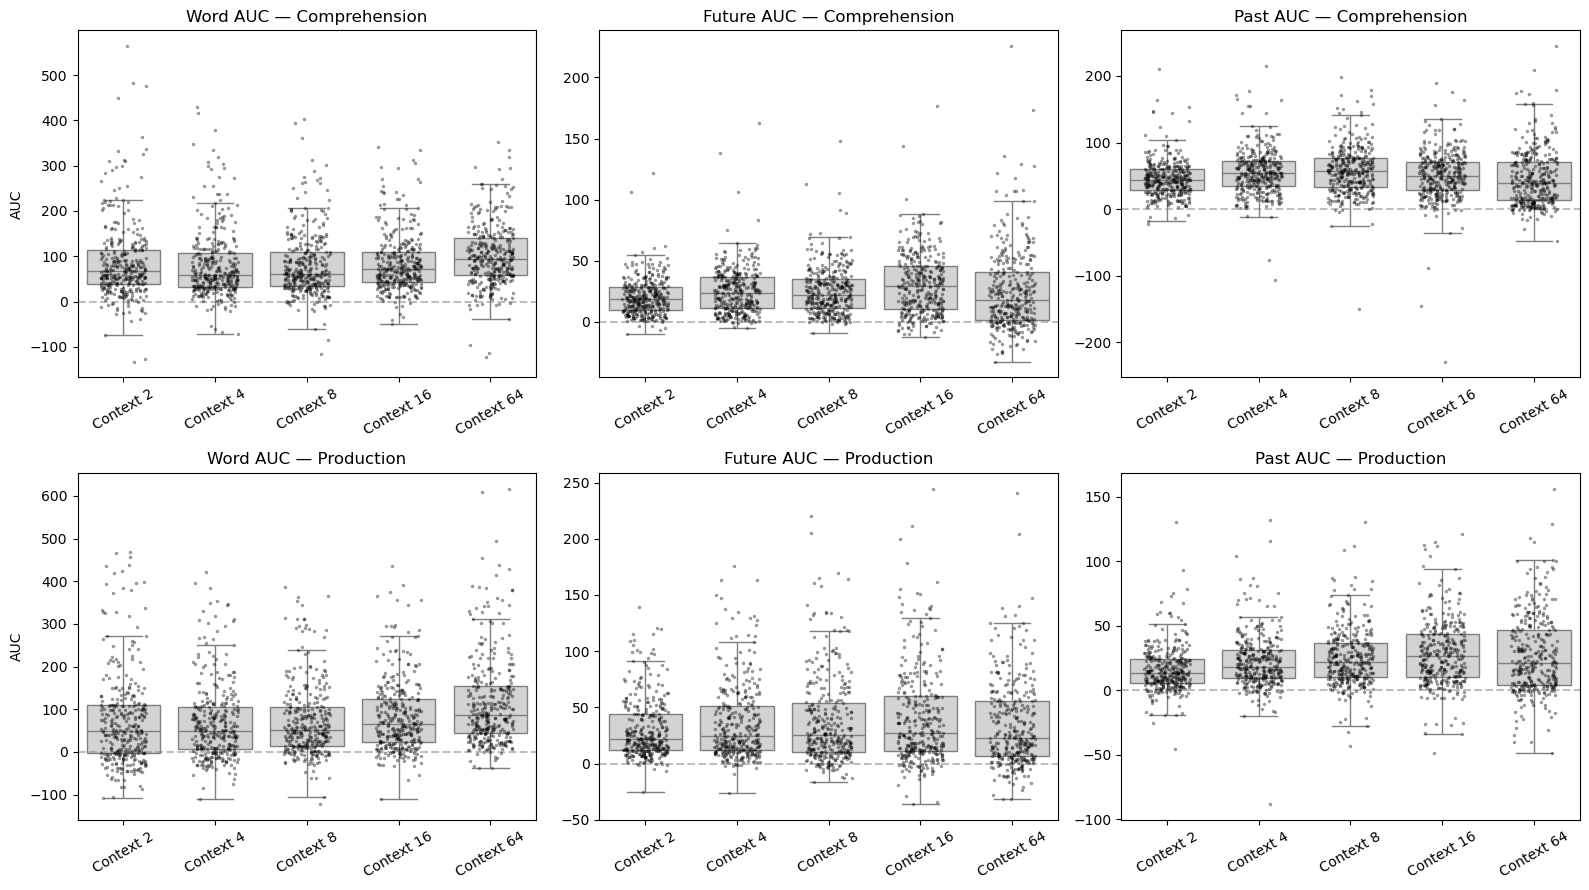

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for row_idx, (auc_long, mode_label) in enumerate([(auc_comp_long, 'Comprehension'), (auc_prod_long, 'Production')]):
    for col_idx, comp_label in enumerate(component_order):
        ax = axes[row_idx, col_idx]
        sub = auc_long[auc_long['component'] == comp_label]
        sns.boxplot(data=sub, x='context', y='auc', order=context_order, showfliers=False, color='lightgray', ax=ax)
        sns.stripplot(data=sub, x='context', y='auc', order=context_order, color='black', size=2.5, alpha=0.4, jitter=0.25, ax=ax)
        ax.axhline(0, color='gray', ls='--', alpha=0.5)
        ax.set_title(f'{comp_label.capitalize()} AUC — {mode_label}')
        ax.set_xlabel('')
        ax.set_ylabel('AUC' if col_idx == 0 else '')
        ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### Plot 4 — Total AUC (Word + Future + Past Summed)

In [ ]:
def compute_total_auc(auc_long):
    """Sum word + future + past AUC per electrode per context."""
    return auc_long.groupby(['subject', 'electrode', 'roi', 'context'], as_index=False)['auc'].sum()


total_auc_comp = compute_total_auc(auc_comp_long)
total_auc_prod = compute_total_auc(auc_prod_long)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, df_plot, mode_label in [(axes[0], total_auc_comp, 'Comprehension'), (axes[1], total_auc_prod, 'Production')]:
    sns.boxplot(data=df_plot, x='context', y='auc', order=context_order, showfliers=False, color='lightsalmon', ax=ax)
    sns.stripplot(data=df_plot, x='context', y='auc', order=context_order, color='black', size=3, alpha=0.4, jitter=0.25, ax=ax)
    ax.axhline(0, color='gray', ls='--', alpha=0.5)
    ax.set_title(f'Total AUC (Word+Future+Past) — {mode_label}')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
axes[0].set_ylabel('Total AUC')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

### Plot 5 — Brain Maps of Relative AUC Change: (Context 64 − Context 2) / Context 2

Uses the summed (word+future+past) AUC per electrode from Plot 4. Values are **percent change**, with negative changes clipped to 0 (so the metric only shows "how much context64 helped" — no decreases are shown). Electrodes where Context 2's AUC is ≤ 0 are dropped (ratio undefined). Colorbar range is **0:100%**, single-hue sequential **Purples** colormap (light = little/no effect, dark purple = large effect).

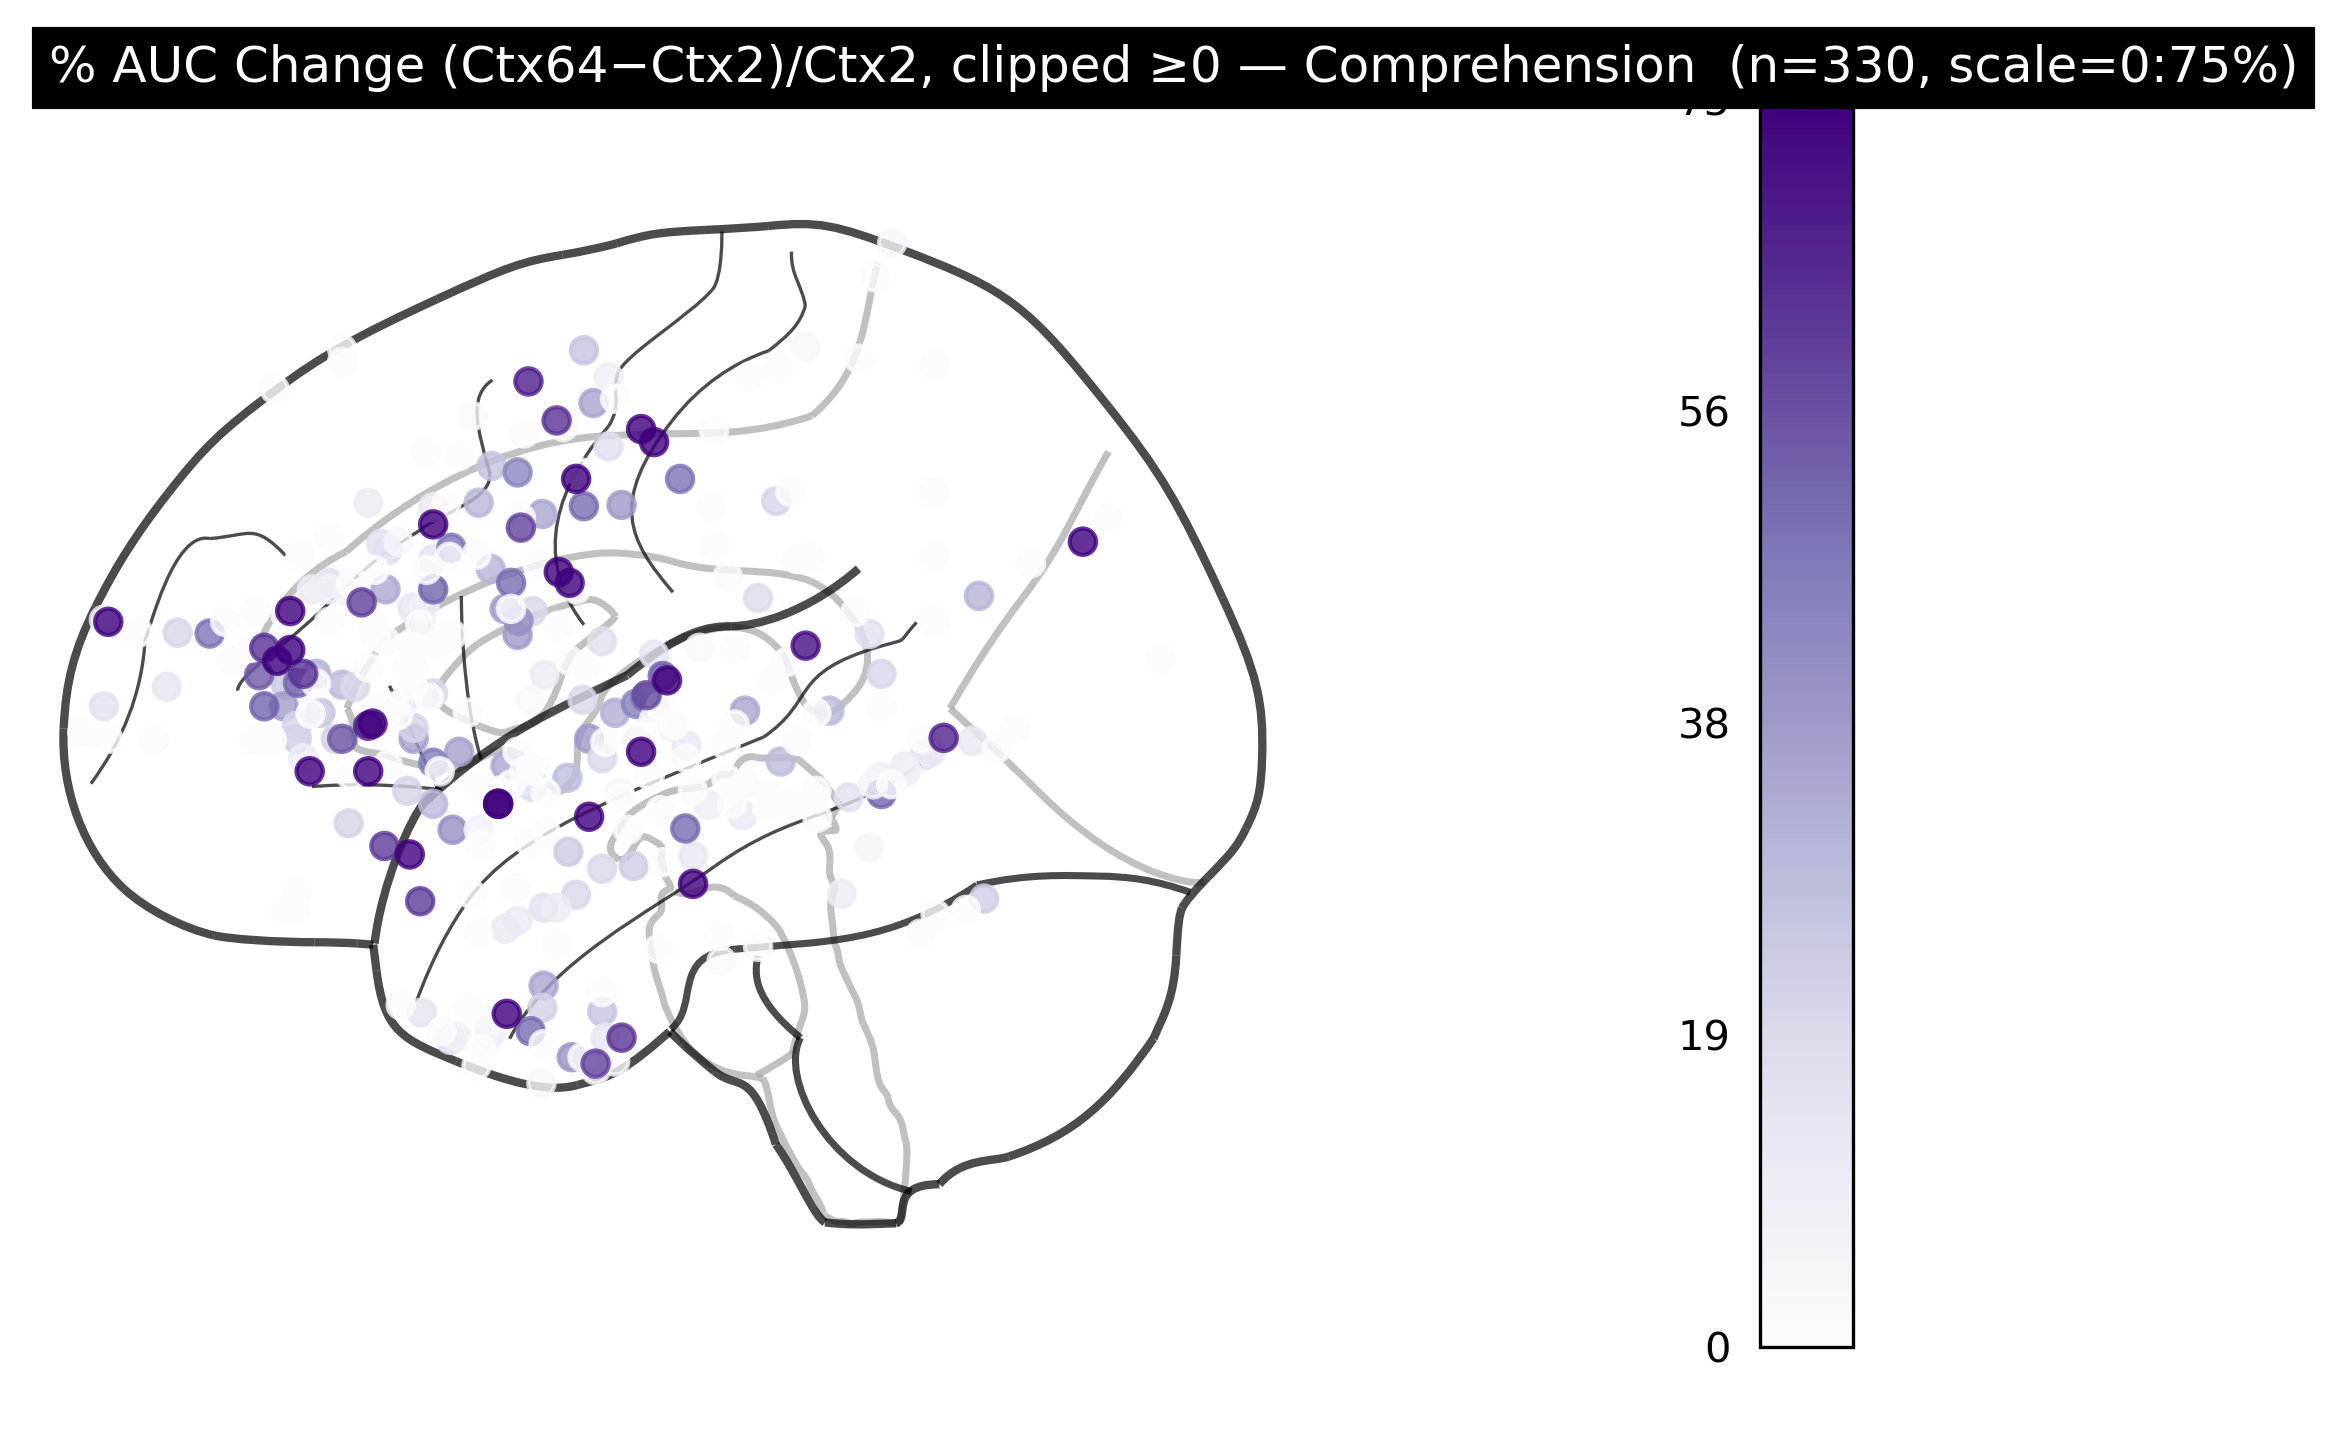

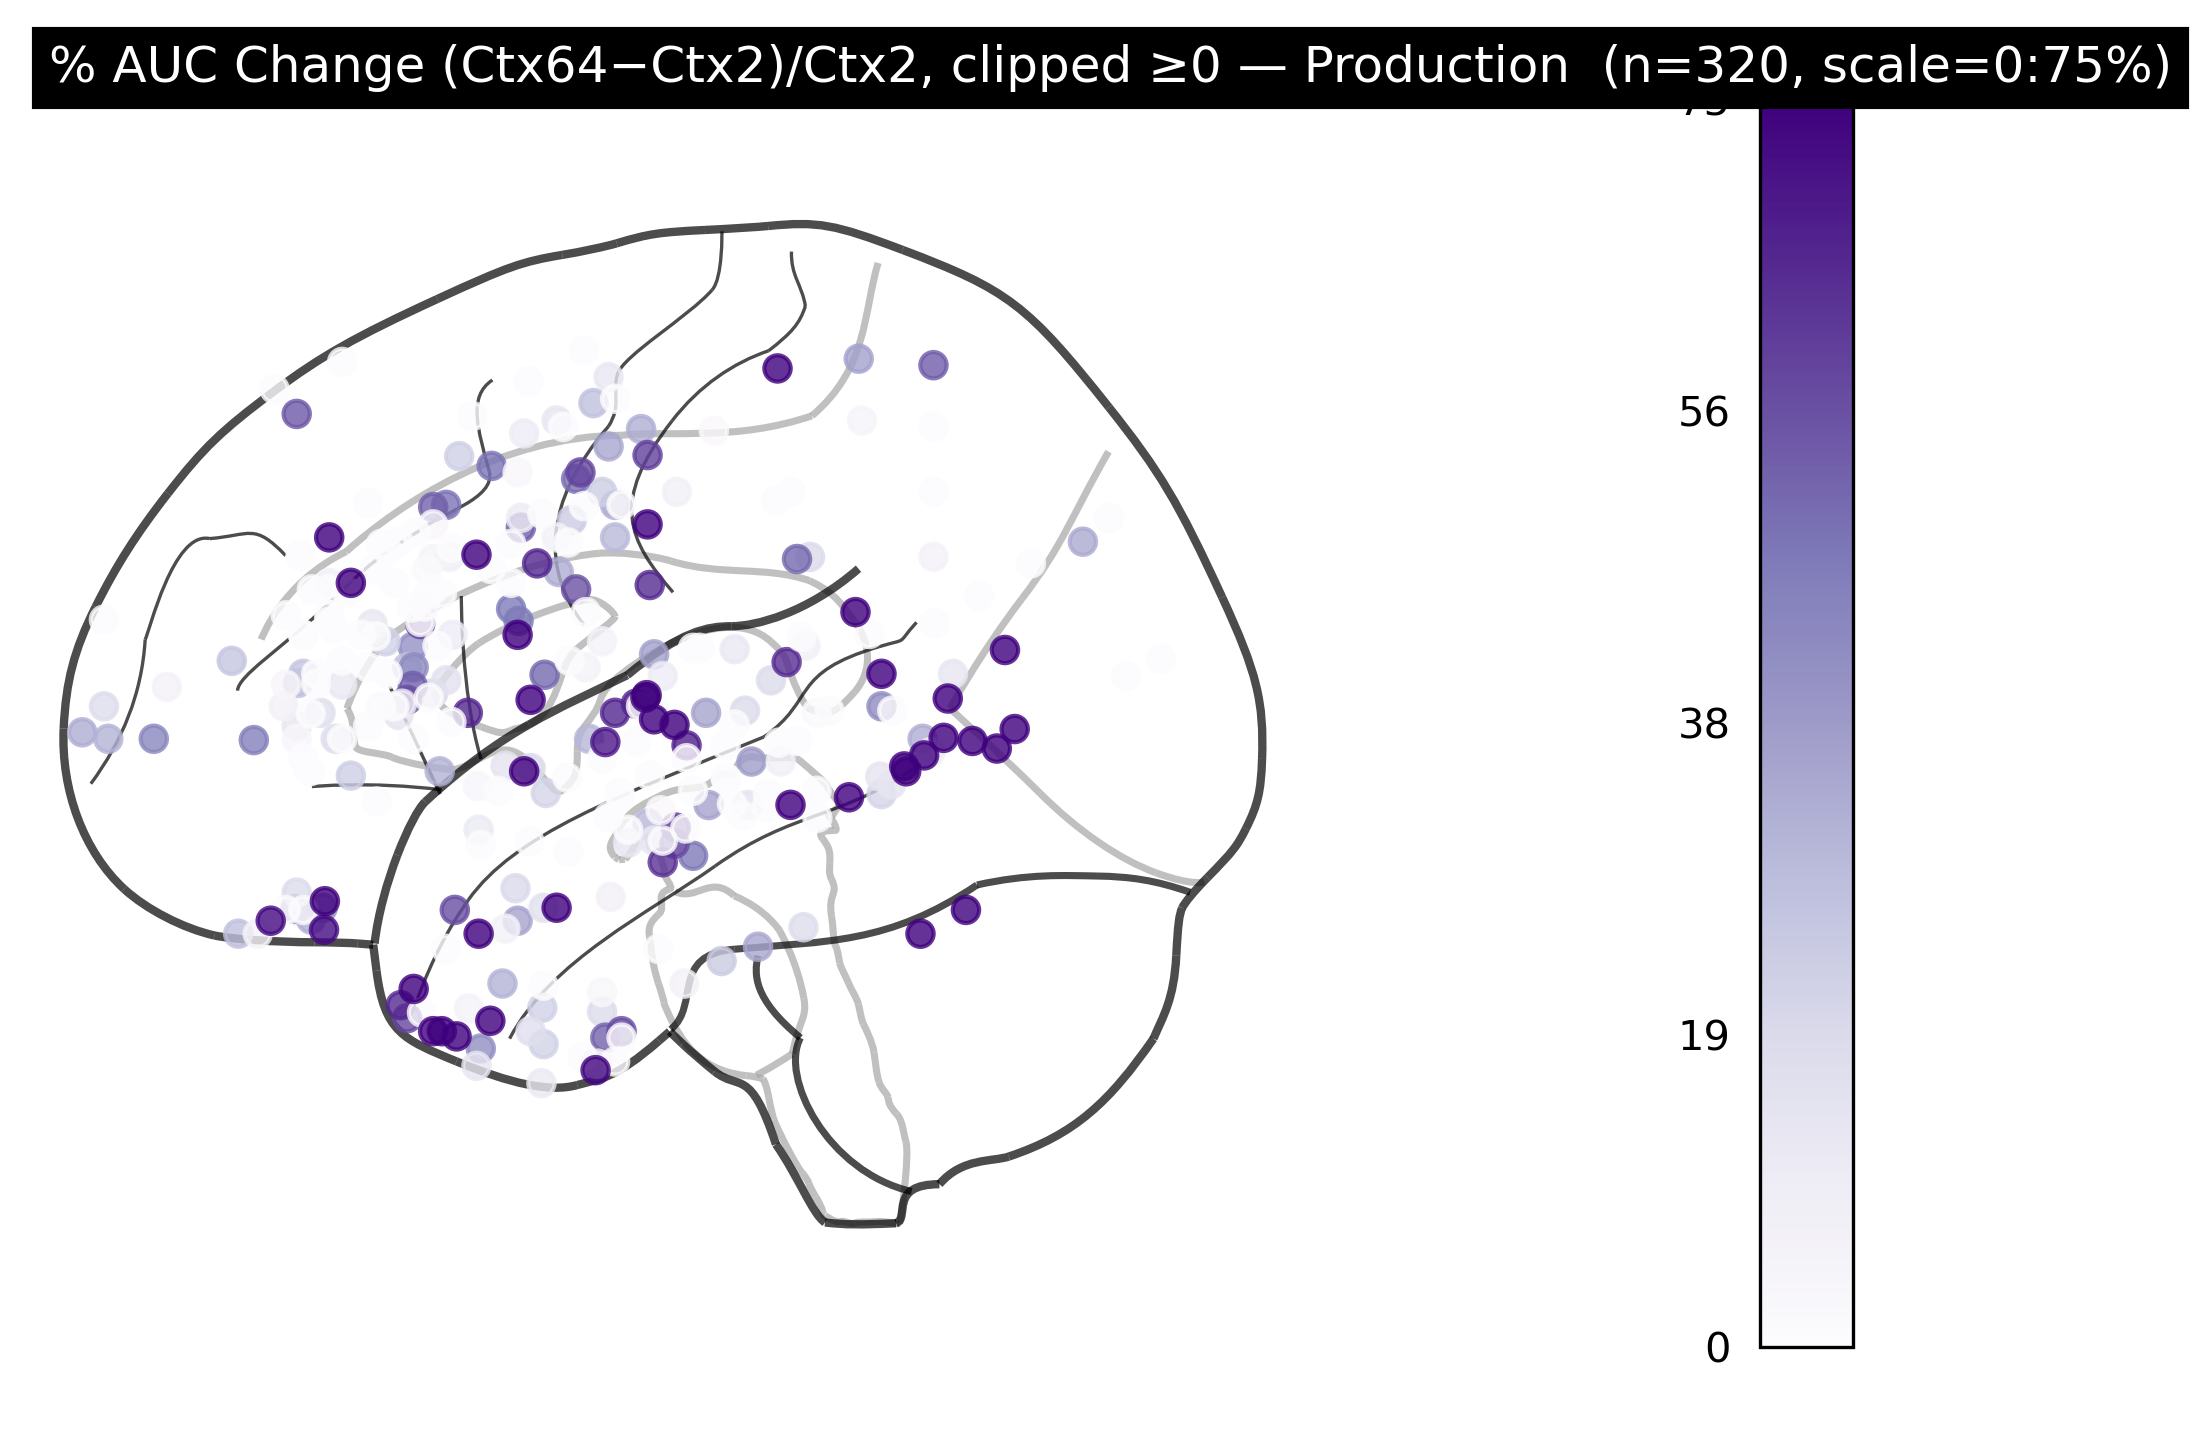

In [125]:
SCALE_CAP_PCT = 75   # colorbar cap, percent (range is 0:cap after clipping negatives to 0)


def compute_relative_change(total_auc_df, ctx_low='Context 2', ctx_high='Context 64'):
    """100 * (AUC_high - AUC_low) / AUC_low per electrode, in PERCENT.
    Drops electrodes with AUC_low <= 0 (ratio undefined). Negative changes are clipped to 0."""
    wide = total_auc_df.pivot_table(index=['subject', 'electrode', 'roi'], columns='context', values='auc').reset_index()
    wide = wide[wide[ctx_low] > 0].copy()
    wide['relative_change'] = 100 * (wide[ctx_high] - wide[ctx_low]) / wide[ctx_low]
    wide = wide.dropna(subset=['relative_change'])
    wide['relative_change'] = wide['relative_change'].clip(lower=0)
    return wide


def plot_relative_change_brainmap(rel_df, mode_label, vmax=SCALE_CAP_PCT):
    """0:vmax colorbar, single-hue sequential Purples colormap."""
    pu.plot_effect_glassbrain(
        rel_df,
        effect_col='relative_change',
        cmap=plt.get_cmap('Purples'),
        vmin=0,
        vmax=vmax,
        title=f"% AUC Change (Ctx64−Ctx2)/Ctx2, clipped ≥0 — {mode_label}  (n={len(rel_df)}, scale=0:{vmax:.0f}%)",
    )


rel_change_comp = compute_relative_change(total_auc_comp)
rel_change_prod = compute_relative_change(total_auc_prod)

plot_relative_change_brainmap(rel_change_comp, 'Comprehension')
plot_relative_change_brainmap(rel_change_prod, 'Production')